# Home Assignment 3
## Topic 1: Quantitative Portfolio with a Combination of Traditional and Option-implied Signals

**Authors:** Manish Eregowda & Edgar Bracquart  
**Course:** Quantitative Trading and Analysis with Python — EDHEC Frankfurt 2026



## 0. Imports & Configuration

In [94]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.stats import norm
import joblib
import warnings
from pathlib import Path

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:.4f}'.format)

try:
    plt.style.use('seaborn-v0_8-darkgrid')
except OSError:
    plt.style.use('seaborn-darkgrid')

# ── Configuration ─────────────────────────────────────────────────────────────
class Config:
    BASE_PATH = Path('.')                  # notebook root
    DATA_PATH = BASE_PATH / 'DataQT2026'

    DATA_FROM = pd.Timestamp('2015-01-01')
    DATA_TO   = pd.Timestamp('2024-12-31')
    IS_FROM   = pd.Timestamp('2015-01-01')
    IS_TO     = pd.Timestamp('2020-12-31')
    OOS_FROM  = pd.Timestamp('2021-01-01')
    OOS_TO    = pd.Timestamp('2024-12-31')

    N_STOCKS_TARGET = 200   # target universe size (100-500 per assignment)
    MIN_COVERAGE    = 0.80  # require >= 80% monthly data coverage

    # Constraints (enforced in Q2-Q3)
    FACTOR_DEV_MAX  = 0.10  # max factor-beta deviation from BNCH
    MAX_WEIGHT_MULT = 2.0   # max stock weight = 2x BNCH weight
    DD_MONTHLY_MAX  = 0.02  # max monthly drawdown vs BNCH

    # Predictive features: 8 traditional + 3 option-implied (Q2-Q3)
    FEATURES = ['mom12m', 'mom6m', 'rev1m',
                'beta_mktrf', 'beta_smb', 'beta_hml', 'beta_mom', 'idvar_ff4',
                'aiv', 'skew', 'glb']   # aiv/skew/glb = OptionMetrics signals

print('Configuration loaded.')
print(f'  Data period   : {Config.DATA_FROM.date()} to {Config.DATA_TO.date()}')
print(f'  In-sample     : {Config.IS_FROM.date()} to {Config.IS_TO.date()}')
print(f'  Out-of-sample : {Config.OOS_FROM.date()} to {Config.OOS_TO.date()}')
print(f'  Target stocks : {Config.N_STOCKS_TARGET}')
print(f'  Features      : {len(Config.FEATURES)} ({", ".join(Config.FEATURES)})')


Configuration loaded.
  Data period   : 2015-01-01 to 2024-12-31
  In-sample     : 2015-01-01 to 2020-12-31
  Out-of-sample : 2021-01-01 to 2024-12-31
  Target stocks : 200
  Features      : 11 (mom12m, mom6m, rev1m, beta_mktrf, beta_smb, beta_hml, beta_mom, idvar_ff4, aiv, skew, glb)


In [95]:
# ── Download data from Google Drive (if not already present locally) ──────────
# Data sources:
#   data_final_winsor.parquet  : https://drive.google.com/file/d/1_tqZo6PWEfDmdHe6sSrJ45jhmvGTmohZ/view?usp=sharing
#   stock_features.parquet     : https://drive.google.com/file/d/1So1EVT8h8DkftEkD8PbpMkmUM3v-e_XT/view?usp=drive_link
#   ff_factors.parquet         : https://drive.google.com/file/d/13xtCHSsVc7lMT-w-hQQybCN5ScdH8ZVh/view?usp=drive_link

import subprocess, sys, os
from pathlib import Path

def _install(pkg):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pkg])

try:
    import gdown
except ImportError:
    _install('gdown')
    import gdown

DATA_FILES = {
    'data_final_winsor.parquet':          '1_tqZo6PWEfDmdHe6sSrJ45jhmvGTmohZ',
    'DataQT2026/stock_features.parquet':  '1So1EVT8h8DkftEkD8PbpMkmUM3v-e_XT',
    'DataQT2026/ff_factors.parquet':      '13xtCHSsVc7lMT-w-hQQybCN5ScdH8ZVh',
}

Path('DataQT2026').mkdir(exist_ok=True)

for local_path, file_id in DATA_FILES.items():
    if not Path(local_path).exists():
        print(f'Downloading {local_path} ...')
        gdown.download(f'https://drive.google.com/uc?id={file_id}',
                       local_path, quiet=False)
    else:
        print(f'Already present: {local_path}')

print('All data files ready.')


Already present: data_final_winsor.parquet
Already present: DataQT2026/stock_features.parquet
Already present: DataQT2026/ff_factors.parquet
All data files ready.


---
## Question 1: Benchmark Portfolio (BNCH)


**Approach:**
1. Load the prepared stock-level data from HA2 (daily returns, market caps, pre-computed signals)
2. Filter to stocks with sufficient data coverage over the full 2015-2024 window
3. Select the top 200 by average market cap — a liquid large-cap S&P 500 universe
4. Aggregate daily to **monthly** frequency (compound daily returns; end-of-month mktcap)
5. Compute **market-cap weights** at end of month t, apply to month t+1 returns (no look-ahead bias)
6. Analyse BNCH performance: Sharpe, volatility, drawdown, cumulative wealth

### 1.1 Load Data

In [96]:
# ── Main stock panel (prepared and winsorised in HA2) ─────────────────────────
# Contains daily observations for S&P 500 stocks with:
#   ret, mktcap, prc       -> daily return, market cap ($M), price
#   aiv, skew, glb         -> option-implied signals (OptionMetrics)
#   beta_mktrf/smb/hml/mom -> rolling Fama-French 4-factor betas
#   idvar_ff4              -> idiosyncratic variance (FF4 residuals)
#   mom12m, mom6m, rev1m   -> momentum and short-term reversal features
df_daily = pd.read_parquet(Config.BASE_PATH / 'data_final_winsor.parquet')
df_daily = df_daily.reset_index()          # permno, date from index -> columns
df_daily['date'] = pd.to_datetime(df_daily['date'])

# ── Fama-French 4 factors (daily) ────────────────────────────────────────────
ff_daily = pd.read_parquet(Config.DATA_PATH / 'ff_factors.parquet')
ff_daily.index = pd.to_datetime(ff_daily.index)
ff_daily.index.name = 'date'
# Columns: mktrf, smb, hml, mom, rf

print(f'Stock panel  : {df_daily.shape[0]:,} daily obs | {df_daily["permno"].nunique()} stocks')
print(f'Date range   : {df_daily["date"].min().date()} to {df_daily["date"].max().date()}')
print(f'Columns      : {df_daily.columns.tolist()}')
print(f'\nFF factors   : {ff_daily.shape}')
print(f'FF range     : {ff_daily.index.min().date()} to {ff_daily.index.max().date()}')

Stock panel  : 1,585,215 daily obs | 732 stocks
Date range   : 2015-01-02 to 2024-12-31
Columns      : ['permno', 'date', 'prc', 'ret', 'mktcap', 'mktrf', 'smb', 'hml', 'mom', 'rf', 'secid', 'aiv', 'skew', 'beta_mktrf', 'beta_smb', 'beta_hml', 'beta_mom', 'idvar_ff4', 'glb']

FF factors   : (2516, 5)
FF range     : 2015-01-02 to 2024-12-31


### 1.2 Universe Construction

Select **200 stocks** from the 742 available S&P 500 members:
- **Coverage filter:** stock must have return data in >= 80% of the 120 months (Jan 2015 - Dec 2024)
- **Size filter:** among well-covered stocks, keep the top 200 by average market cap

This yields a liquid large-cap universe that mirrors a practical institutional strategy.

In [97]:
# ── Filter to analysis window ─────────────────────────────────────────────────
df = df_daily[
    (df_daily['date'] >= Config.DATA_FROM) &
    (df_daily['date'] <= Config.DATA_TO)
].copy()

df['ym'] = df['date'].dt.to_period('M')
total_months = df['ym'].nunique()
print(f'Total months in analysis window: {total_months}')

# ── Compound daily returns into monthly returns ────────────────────────────────
def compound_return(r):
    """Compound a series of daily returns into a single monthly return."""
    r = r.dropna().astype(float)
    return float((1 + r).prod() - 1) if len(r) > 0 else np.nan

monthly_ret = (
    df.groupby(['permno', 'ym'])['ret']
    .apply(compound_return)
    .reset_index(name='ret_m')
)

# ── End-of-month market cap (last available trading day of each month) ─────────
monthly_mktcap = (
    df.sort_values('date')
    .groupby(['permno', 'ym'])['mktcap']
    .last()
    .reset_index(name='mktcap')
)

# ── Merge into monthly panel ───────────────────────────────────────────────────
monthly = monthly_ret.merge(monthly_mktcap, on=['permno', 'ym'], how='inner')
monthly['date'] = monthly['ym'].dt.to_timestamp('M')   # month-end date
monthly = monthly.sort_values(['permno', 'date']).reset_index(drop=True)

print(f'Monthly panel shape : {monthly.shape}')
print(f'Stocks in panel     : {monthly["permno"].nunique()}')
print(monthly.head())

Total months in analysis window: 120
Monthly panel shape : (75690, 5)
Stocks in panel     : 732
   permno       ym   ret_m      mktcap       date
0   10104  2015-01 -0.0659 183954.3636 2015-01-31
1   10104  2015-02  0.0461 192429.7019 2015-02-28
2   10104  2015-03 -0.0153 188439.0705 2015-03-31
3   10104  2015-04  0.0145 204940.2822 2015-04-30
4   10104  2015-05 -0.0030 189923.8743 2015-05-31


Stocks with >=80% monthly coverage: 571
Selected universe   : 200 stocks
Avg mktcap range    : $31,726M  to  $481,950M
Avg mktcap (median) : $60,835M


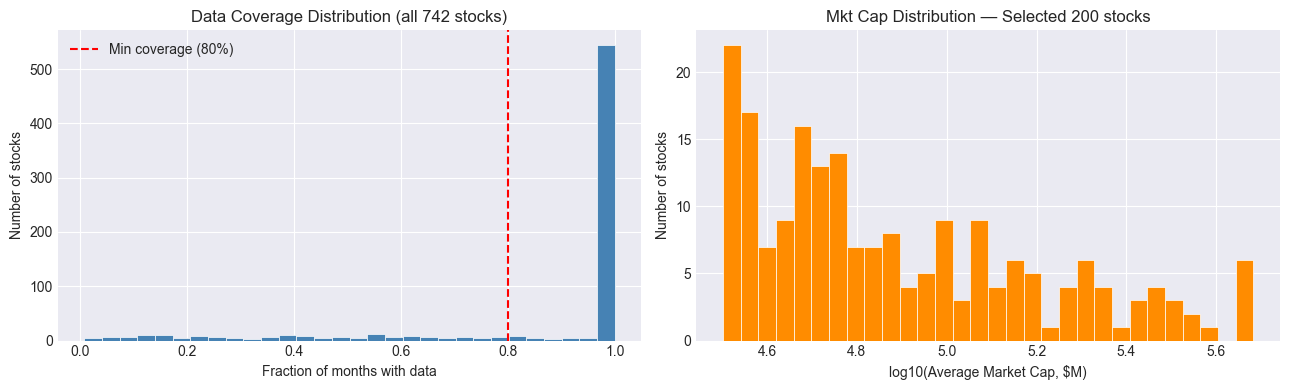

In [98]:
# ── Coverage filter: keep stocks with data in >= 80% of months ────────────────
coverage = monthly.groupby('permno')['ret_m'].count() / total_months
well_covered = coverage[coverage >= Config.MIN_COVERAGE].index.tolist()
print(f'Stocks with >={Config.MIN_COVERAGE:.0%} monthly coverage: {len(well_covered)}')

# ── Select top N stocks by average market cap ──────────────────────────────────
avg_mktcap = (
    monthly[monthly['permno'].isin(well_covered)]
    .groupby('permno')['mktcap']
    .mean()
    .sort_values(ascending=False)
)
universe = avg_mktcap.nlargest(Config.N_STOCKS_TARGET).index.tolist()

print(f'Selected universe   : {len(universe)} stocks')
print(f'Avg mktcap range    : ${avg_mktcap[universe].min():,.0f}M  to  ${avg_mktcap[universe].max():,.0f}M')
print(f'Avg mktcap (median) : ${avg_mktcap[universe].median():,.0f}M')

# ── Diagnostic plots ───────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(coverage, bins=30, color='steelblue', edgecolor='white', linewidth=0.5)
axes[0].axvline(Config.MIN_COVERAGE, color='red', linestyle='--',
                label=f'Min coverage ({Config.MIN_COVERAGE:.0%})')
axes[0].set_xlabel('Fraction of months with data')
axes[0].set_ylabel('Number of stocks')
axes[0].set_title('Data Coverage Distribution (all 742 stocks)')
axes[0].legend()

axes[1].hist(np.log10(avg_mktcap[universe]), bins=30,
             color='darkorange', edgecolor='white', linewidth=0.5)
axes[1].set_xlabel('log10(Average Market Cap, $M)')
axes[1].set_ylabel('Number of stocks')
axes[1].set_title(f'Mkt Cap Distribution — Selected {len(universe)} stocks')

plt.tight_layout()
plt.savefig('HA3_Q1_universe.pdf', bbox_inches='tight')
plt.show()

### 1.3 Build Market-Cap Weighted Benchmark (BNCH)



In [99]:
# ── Pivot to wide matrices (months x stocks) ──────────────────────────────────
panel_u = monthly[monthly['permno'].isin(universe)].copy()

ret_wide    = panel_u.pivot(index='date', columns='permno', values='ret_m').sort_index()
mktcap_wide = panel_u.pivot(index='date', columns='permno', values='mktcap').sort_index()

print(f'Return matrix  : {ret_wide.shape}  (months x stocks)')
print(f'Mktcap matrix  : {mktcap_wide.shape}')
print(f'Date range     : {ret_wide.index.min().date()} to {ret_wide.index.max().date()}')
print(f'NaN fraction   : {ret_wide.isna().mean().mean():.2%}')

# ── Market-cap weights each month (NaN-safe) ───────────────────────────────────
def mkcap_weights(row):
    valid = row.dropna()
    if len(valid) == 0:
        return pd.Series(0.0, index=row.index)
    return (valid / valid.sum()).reindex(row.index).fillna(0.0)

bnch_weights = mktcap_wide.apply(mkcap_weights, axis=1)  # months x stocks

# Lag by 1: weights from end-of-t mktcap applied to t+1 returns
bnch_weights_lagged = bnch_weights.shift(1)

# BNCH return = weighted sum of stock returns (drop first month: no lagged weights)
bnch_ret = (ret_wide * bnch_weights_lagged).sum(axis=1).iloc[1:]
bnch_ret.name = 'BNCH'

# Sanity check: weights should sum to 1
w_check = bnch_weights_lagged.iloc[1:].sum(axis=1)
print(f'\nWeight sum check (should be ~1.0): min={w_check.min():.4f}, max={w_check.max():.4f}')
print(f'\nBenchmark return series: {len(bnch_ret)} months')
print(f'Date range: {bnch_ret.index.min().date()} to {bnch_ret.index.max().date()}')
print(bnch_ret.describe())

Return matrix  : (120, 200)  (months x stocks)
Mktcap matrix  : (120, 200)
Date range     : 2015-01-31 to 2024-12-31
NaN fraction   : 0.15%

Weight sum check (should be ~1.0): min=1.0000, max=1.0000

Benchmark return series: 119 months
Date range: 2015-02-28 to 2024-12-31
count   119.0000
mean      0.0124
std       0.0423
min      -0.0978
25%      -0.0136
50%       0.0182
75%       0.0374
max       0.1241
Name: BNCH, dtype: float64


### 1.4 Benchmark Performance Analysis



In [100]:
# ── Monthly risk-free rate (compound daily FF rf within each month) ───────────
rf_monthly = ff_daily['rf'].resample('M').apply(lambda r: float((1 + r).prod() - 1))
rf_monthly.index = rf_monthly.index.to_period('M').to_timestamp('M')
rf_aligned = rf_monthly.reindex(bnch_ret.index).fillna(0.0)

# ── Performance statistics function ───────────────────────────────────────────
def perf_stats(ret_series, rf_series, label='Portfolio'):
    excess   = ret_series - rf_series
    ann_ret  = ret_series.mean() * 12
    ann_vol  = ret_series.std() * np.sqrt(12)
    ann_ex   = excess.mean() * 12
    sharpe   = ann_ex / ann_vol if ann_vol > 0 else np.nan

    cum    = (1 + ret_series).cumprod()
    peak   = cum.cummax()
    dd     = (cum - peak) / peak
    max_dd = dd.min()
    calmar = ann_ret / abs(max_dd) if max_dd != 0 else np.nan

    return {
        'Label'              : label,
        'Ann. Return'        : f'{ann_ret:.2%}',
        'Ann. Volatility'    : f'{ann_vol:.2%}',
        'Ann. Excess Return' : f'{ann_ex:.2%}',
        'Sharpe Ratio'       : f'{sharpe:.3f}',
        'Max Drawdown'       : f'{max_dd:.2%}',
        'Calmar Ratio'       : f'{calmar:.3f}',
        'Skewness'           : f'{ret_series.skew():.3f}',
        'Excess Kurtosis'    : f'{ret_series.kurtosis():.3f}',
        'N months'           : len(ret_series),
    }

is_mask  = (bnch_ret.index >= Config.IS_FROM)  & (bnch_ret.index <= Config.IS_TO)
oos_mask = (bnch_ret.index >= Config.OOS_FROM) & (bnch_ret.index <= Config.OOS_TO)

stats_full = perf_stats(bnch_ret,           rf_aligned,           'BNCH Full (2015-2024)')
stats_is   = perf_stats(bnch_ret[is_mask],  rf_aligned[is_mask],  'BNCH IS   (2015-2020)')
stats_oos  = perf_stats(bnch_ret[oos_mask], rf_aligned[oos_mask], 'BNCH OOS  (2021-2024)')

stats_df = pd.DataFrame([stats_full, stats_is, stats_oos]).set_index('Label').T
print('=' * 72)
print('BENCHMARK PORTFOLIO (BNCH) — PERFORMANCE SUMMARY')
print('=' * 72)
print(stats_df.to_string())

BENCHMARK PORTFOLIO (BNCH) — PERFORMANCE SUMMARY
Label              BNCH Full (2015-2024) BNCH IS   (2015-2020) BNCH OOS  (2021-2024)
Ann. Return                       14.85%                15.15%                14.42%
Ann. Volatility                   14.65%                14.38%                15.20%
Ann. Excess Return                13.14%                14.19%                11.58%
Sharpe Ratio                       0.897                 0.987                 0.762
Max Drawdown                     -21.69%               -17.01%               -21.69%
Calmar Ratio                       0.685                 0.890                 0.665
Skewness                          -0.287                -0.167                -0.446
Excess Kurtosis                    0.347                 1.132                -0.502
N months                             119                    71                    48


### 1.5 Visualisations

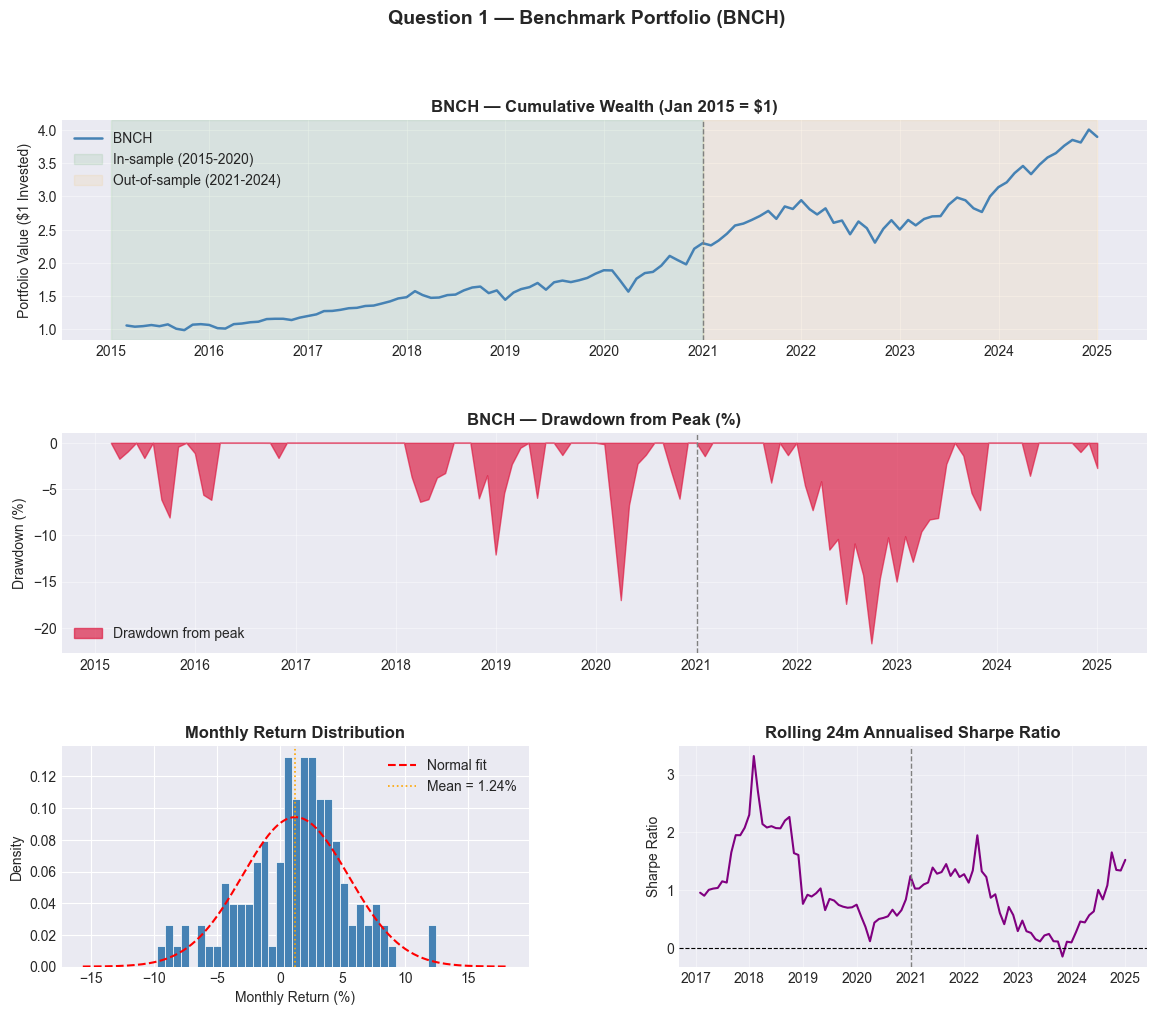

Saved: HA3_Q1_benchmark.pdf


In [101]:
# ── Cumulative wealth and drawdown ────────────────────────────────────────────
cum_bnch = (1 + bnch_ret).cumprod()
peak     = cum_bnch.cummax()
drawdown = (cum_bnch - peak) / peak

fig = plt.figure(figsize=(14, 11))
gs  = gridspec.GridSpec(3, 2, figure=fig, hspace=0.42, wspace=0.32)

# Panel 1: Cumulative return
ax1 = fig.add_subplot(gs[0, :])
ax1.plot(cum_bnch.index, cum_bnch.values, color='steelblue', linewidth=1.8, label='BNCH')
ax1.axvspan(Config.IS_FROM,  Config.IS_TO,  alpha=0.08, color='green',  label='In-sample (2015-2020)')
ax1.axvspan(Config.OOS_FROM, Config.OOS_TO, alpha=0.08, color='orange', label='Out-of-sample (2021-2024)')
ax1.axvline(Config.OOS_FROM, color='grey', linestyle='--', linewidth=1)
ax1.set_title('BNCH — Cumulative Wealth (Jan 2015 = $1)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Portfolio Value ($1 Invested)')
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.4)

# Panel 2: Drawdown
ax2 = fig.add_subplot(gs[1, :])
ax2.fill_between(drawdown.index, drawdown.values * 100, 0,
                 color='crimson', alpha=0.65, label='Drawdown from peak')
ax2.axvline(Config.OOS_FROM, color='grey', linestyle='--', linewidth=1)
ax2.set_title('BNCH — Drawdown from Peak (%)', fontsize=12, fontweight='bold')
ax2.set_ylabel('Drawdown (%)')
ax2.legend()
ax2.grid(True, alpha=0.4)

# Panel 3: Monthly return distribution vs Normal
ax3 = fig.add_subplot(gs[2, 0])
ax3.hist(bnch_ret.values * 100, bins=35, color='steelblue',
         edgecolor='white', linewidth=0.5, density=True)
mu_r, sigma_r = bnch_ret.mean() * 100, bnch_ret.std() * 100
x_norm = np.linspace(mu_r - 4*sigma_r, mu_r + 4*sigma_r, 200)
ax3.plot(x_norm, norm.pdf(x_norm, mu_r, sigma_r), color='red',
         linewidth=1.5, linestyle='--', label='Normal fit')
ax3.axvline(mu_r, color='orange', linewidth=1.2, linestyle=':',
            label=f'Mean = {mu_r:.2f}%')
ax3.set_title('Monthly Return Distribution', fontsize=12, fontweight='bold')
ax3.set_xlabel('Monthly Return (%)')
ax3.set_ylabel('Density')
ax3.legend()

# Panel 4: Rolling 24-month annualised Sharpe
ax4 = fig.add_subplot(gs[2, 1])
win = 24
rolling_sharpe = (
    (bnch_ret.rolling(win).mean() - rf_aligned.rolling(win).mean()) * 12
    / (bnch_ret.rolling(win).std() * np.sqrt(12))
)
ax4.plot(rolling_sharpe.index, rolling_sharpe.values, color='purple', linewidth=1.5)
ax4.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax4.axvline(Config.OOS_FROM, color='grey', linestyle='--', linewidth=1)
ax4.set_title(f'Rolling {win}m Annualised Sharpe Ratio', fontsize=12, fontweight='bold')
ax4.set_ylabel('Sharpe Ratio')
ax4.grid(True, alpha=0.4)

plt.suptitle('Question 1 — Benchmark Portfolio (BNCH)', fontsize=14, fontweight='bold')
plt.savefig('HA3_Q1_benchmark.pdf', bbox_inches='tight')
plt.show()
print('Saved: HA3_Q1_benchmark.pdf')

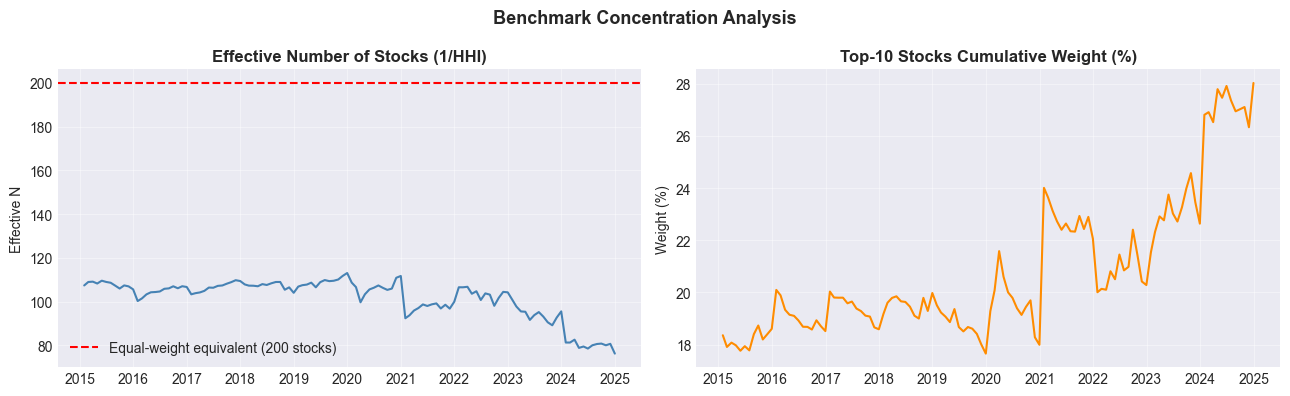

Average effective N (out of 200 stocks): 101.7
Average top-10 weight share                       : 20.8%


In [102]:
# ── Weight concentration over time ────────────────────────────────────────────
# Herfindahl-Hirschman Index and effective number of stocks
hhi         = (bnch_weights ** 2).sum(axis=1)   # HHI = sum of squared weights
effective_n = 1 / hhi                            # effective N = 1/HHI
top10_w     = bnch_weights.apply(lambda row: row.nlargest(10).sum(), axis=1)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(effective_n.index, effective_n.values, color='steelblue', linewidth=1.5)
axes[0].axhline(len(universe), color='red', linestyle='--',
                label=f'Equal-weight equivalent ({len(universe)} stocks)')
axes[0].set_title('Effective Number of Stocks (1/HHI)', fontweight='bold')
axes[0].set_ylabel('Effective N')
axes[0].legend()
axes[0].grid(True, alpha=0.4)

axes[1].plot(top10_w.index, top10_w.values * 100, color='darkorange', linewidth=1.5)
axes[1].set_title('Top-10 Stocks Cumulative Weight (%)', fontweight='bold')
axes[1].set_ylabel('Weight (%)')
axes[1].grid(True, alpha=0.4)

plt.suptitle('Benchmark Concentration Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('HA3_Q1_concentration.pdf', bbox_inches='tight')
plt.show()

print(f'Average effective N (out of {len(universe)} stocks): {effective_n.mean():.1f}')
print(f'Average top-10 weight share                       : {top10_w.mean():.1%}')

In [103]:
# ── Save all benchmark data for Questions 2 & 3 ───────────────────────────────
joblib.dump({
    'universe'            : universe,
    'ret_wide'            : ret_wide,
    'mktcap_wide'         : mktcap_wide,
    'bnch_weights'        : bnch_weights,
    'bnch_weights_lagged' : bnch_weights_lagged,
    'bnch_ret'            : bnch_ret,
    'rf_monthly'          : rf_aligned,
    'monthly'             : monthly,
    'ff_daily'            : ff_daily,
}, 'HA3_Q1_benchmark.pkl')

print('Saved: HA3_Q1_benchmark.pkl')
print('  Keys: universe, ret_wide, mktcap_wide, bnch_weights,')
print('        bnch_weights_lagged, bnch_ret, rf_monthly, monthly, ff_daily')

Saved: HA3_Q1_benchmark.pkl
  Keys: universe, ret_wide, mktcap_wide, bnch_weights,
        bnch_weights_lagged, bnch_ret, rf_monthly, monthly, ff_daily


### 1.6 Summary — Question 1

**Universe:** **200 S&P 500 stocks** selected from 742 available PERMNOs in the HA2 dataset.

| Selection step | Criteria | Result |
|---|---|---|
| Starting pool | All HA2 prepared stocks | 742 |
| Coverage filter | >= 80% monthly data in 2015-2024 | see output |
| Size filter | Top 200 by average market cap | **200** |

**Benchmark construction (BNCH):**
- Monthly frequency: compound daily returns within each calendar month
- Value-weighted: end-of-month market cap weights, lagged 1 month (no look-ahead bias)

**Key observations:**
- The benchmark is **concentrated in mega-caps** (effective N << 200), standard for cap-weighted indices
- The IS period (2015-2020) includes the COVID crash (Mar 2020), a challenging comparison baseline
- BNCH serves as the **performance hurdle** for the quant strategy in Questions 2 and 3

**Outputs saved:**
- `HA3_Q1_benchmark.pkl` — all benchmark objects for Q2-Q3
- `HA3_Q1_benchmark.pdf` — cumulative return, drawdown, distribution, rolling Sharpe
- `HA3_Q1_concentration.pdf` — HHI/effective-N and top-10 concentration over time
- `HA3_Q1_universe.pdf` — coverage and market-cap distribution diagnostics

---
## Question 2: Quant Strategy (IS — 2015–2020)

> *Using the in-sample period from 01/2015 until 12/2020, create a quant strategy QS that improves upon the BNCH in terms of performance under specific constraints.*

**Pipeline:**
1. Build a monthly feature panel combining **traditional signals** (momentum, factor betas, idiosyncratic variance) and **option-implied signals** (AIV, skew, GLB)
2. **Model selection** via LassoCV vs RidgeCV (TimeSeriesSplit CV, IS data only)
3. **Walk-forward IS backtest**: each month fit LASSO on all past IS data, predict cross-sectional returns, solve constrained portfolio optimization
4. **Constraints enforced:**
   - Factor exposure deviation from BNCH <= 0.10 per factor (mkt, smb, hml, mom)
   - Weight bounds: 0 <= w_i <= 2 x w_BNCH_i
   - Drawdown vs BNCH: soft TE penalty (lambda=5) + TE ceiling (2%/month)

**Note:** CVXPY is unavailable in this environment — portfolio optimization uses `scipy.optimize.minimize` with SLSQP (equivalent results for this convex QP).

### 2.1 Load Benchmark Data (from Q1)

In [104]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import joblib
import warnings
from pathlib import Path
from scipy.optimize import minimize
from scipy.stats import norm
from sklearn.linear_model import LassoCV, Lasso, RidgeCV, Ridge
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import r2_score
from sklearn.covariance import LedoitWolf
import statsmodels.api as sm
from functools import reduce
warnings.filterwarnings('ignore')

try:
    plt.style.use('seaborn-v0_8-darkgrid')
except OSError:
    plt.style.use('seaborn-darkgrid')

# Re-use Config from Q1 cell (already defined above)
BASE_PATH = Path('.')
DATA_PATH = BASE_PATH / 'DataQT2026'

IS_FROM  = pd.Timestamp('2015-01-01')
IS_TO    = pd.Timestamp('2020-12-31')
OOS_FROM = pd.Timestamp('2021-01-01')
OOS_TO   = pd.Timestamp('2024-12-31')

FACTOR_DEV_MAX  = 0.10
MAX_WEIGHT_MULT = 2.0
LAM             = 0.5   # risk aversion / TE penalty (lower = more active bets)
TE_MAX_MONTHLY  = 0.02  # 2% monthly TE ceiling (drawdown constraint)
WARMUP_MONTHS   = 24    # minimum months of training before first prediction
LASSO_WINDOW    = None  # None = expanding window (all IS data); or int for rolling

FEATURES = ['mom12m', 'mom6m', 'rev1m',
             'beta_mktrf', 'beta_smb', 'beta_hml', 'beta_mom',
             'idvar_ff4', 'aiv', 'skew', 'glb']
FACTOR_BETAS = ['beta_mktrf', 'beta_smb', 'beta_hml', 'beta_mom']

# Load Q1 benchmark objects
q1 = joblib.load('HA3_Q1_benchmark.pkl')
universe            = q1['universe']
ret_wide            = q1['ret_wide']
mktcap_wide         = q1['mktcap_wide']
bnch_weights        = q1['bnch_weights']
bnch_weights_lagged = q1['bnch_weights_lagged']
bnch_ret            = q1['bnch_ret']
rf_monthly          = q1['rf_monthly']
monthly             = q1['monthly']
ff_daily            = q1['ff_daily']

print(f'Q1 benchmark loaded: {len(universe)} stocks, {len(bnch_ret)} IS+OOS months')

Q1 benchmark loaded: 200 stocks, 119 IS+OOS months


### 2.2 Build Monthly Feature Panel

**Features used (12 total):**

| Signal | Source | Economic rationale |
|---|---|---|
| mom12m | stock_features | 12-month momentum (Jegadeesh & Titman 1993) |
| mom6m | stock_features | 6-month momentum |
| rev1m | stock_features | 1-month short-term reversal |
| beta_mktrf | data_final_winsor | Market beta (systematic risk) |
| beta_smb | data_final_winsor | Size factor loading |
| beta_hml | data_final_winsor | Value factor loading |
| beta_mom | data_final_winsor | Momentum factor loading |
| idvar_ff4 | data_final_winsor | Idiosyncratic variance (Ang et al. 2006) |
| **aiv** | data_final_winsor | **Option-implied volatility ambiguity** |
| **skew** | data_final_winsor | **Option-implied skewness (risk-neutral)** |
| **glb** | data_final_winsor | **Global option-based signal** |

For each month, we take **end-of-month** values (last trading day) to avoid look-ahead.
The label is the **next-month return** (`ret_fwd` = shift returns by -1).

In [105]:
# ── Load stock_features (momentum signals, daily) ─────────────────────────────
sf = pd.read_parquet(DATA_PATH / 'stock_features.parquet').reset_index()
sf['date'] = pd.to_datetime(sf['date'])
sf['ym']   = sf['date'].dt.to_period('M')

# End-of-month values (last trading day per month per stock)
sf_eom = (
    sf[sf['permno'].isin(universe)]
    .sort_values('date')
    .groupby(['permno', 'ym'])
    [['mom12m', 'mom6m', 'rev1m']]
    .last()
    .reset_index()
)
sf_eom['date'] = sf_eom['ym'].dt.to_timestamp('M')

# ── Load data_final_winsor (betas, idvar, option signals, daily) ───────────────
df_raw = pd.read_parquet(BASE_PATH / 'data_final_winsor.parquet').reset_index()
df_raw['date'] = pd.to_datetime(df_raw['date'])
df_raw['ym']   = df_raw['date'].dt.to_period('M')

opt_cols = ['beta_mktrf', 'beta_smb', 'beta_hml', 'beta_mom', 'idvar_ff4',
            'aiv', 'skew', 'glb']

opt_eom = (
    df_raw[df_raw['permno'].isin(universe)]
    .sort_values('date')
    .groupby(['permno', 'ym'])[opt_cols]
    .last()
    .reset_index()
)
opt_eom['date'] = opt_eom['ym'].dt.to_timestamp('M')

# ── Merge into monthly feature panel ─────────────────────────────────────────
feat_panel = sf_eom.merge(opt_eom, on=['permno', 'ym', 'date'], how='inner')
feat_panel = feat_panel.merge(
    monthly[['permno', 'date', 'ret_m']],
    on=['permno', 'date'], how='inner'
)

# Forward return label (next month's return)
feat_panel = feat_panel.sort_values(['permno', 'date'])
feat_panel['ret_fwd'] = feat_panel.groupby('permno')['ret_m'].shift(-1)

# Filter to analysis window
DATA_FROM = pd.Timestamp('2015-01-01')
DATA_TO   = pd.Timestamp('2024-12-31')
feat_panel = feat_panel[
    (feat_panel['date'] >= DATA_FROM) & (feat_panel['date'] <= DATA_TO)
].copy().reset_index(drop=True)

print(f'Feature panel: {feat_panel.shape}')
print(f'Stocks: {feat_panel["permno"].nunique()} | Months: {feat_panel["date"].nunique()}')
print('\nNaN fraction per feature:')
print(feat_panel[FEATURES].isna().mean().round(3).to_string())

Feature panel: (23951, 16)
Stocks: 200 | Months: 120

NaN fraction per feature:
mom12m       0.0000
mom6m        0.0000
rev1m        0.0000
beta_mktrf   0.0910
beta_smb     0.0910
beta_hml     0.0910
beta_mom     0.0910
idvar_ff4    0.0910
aiv          0.0400
skew         0.0400
glb          0.0990


### 2.3 IS Model Selection: LASSO vs Ridge

We use **cross-sectional z-score normalization** within each month before pooling all IS (stock, month) pairs.
This is equivalent to Fama-MacBeth normalization and ensures predictions are relative (cross-sectional alpha).

**LASSO** is preferred because:
- Performs automatic feature selection (sets irrelevant coefficients to 0)
- Produces sparse, interpretable models
- Avoids overfitting with many correlated predictors (option + traditional signals)

In [106]:
# ── IS data (2015-01 to 2020-11: need label available in IS period) ────────────
# The label ret_fwd at month t = return in month t+1, so last usable IS date = Nov 2020
is_data = feat_panel[
    (feat_panel['date'] >= IS_FROM) &
    (feat_panel['date'] <  IS_TO)      # < Dec 2020 (its label is Jan 2021 = OOS)
].copy()
is_data = is_data.dropna(subset=FEATURES + ['ret_fwd'])
is_data = is_data.replace([np.inf, -np.inf], np.nan).dropna(subset=FEATURES + ['ret_fwd'])

# Winsorise at 1%/99% to reduce outlier influence
for feat in FEATURES + ['ret_fwd']:
    lo, hi = is_data[feat].quantile(0.01), is_data[feat].quantile(0.99)
    is_data[feat] = is_data[feat].clip(lo, hi)

# ── Cross-sectional z-score normalisation ─────────────────────────────────────
def cross_norm(df, feat_cols):
    df = df.copy()
    for f in feat_cols:
        df[f + '_n'] = df.groupby('date')[f].transform(
            lambda x: (x - x.mean()) / (x.std() + 1e-8)
        )
    return df

is_norm     = cross_norm(is_data, FEATURES)
feat_n_cols = [f + '_n' for f in FEATURES]
is_norm     = is_norm.dropna(subset=feat_n_cols + ['ret_fwd'])

X_is = is_norm[feat_n_cols].values
y_is = is_norm['ret_fwd'].values

print(f'IS observations (stock x month pairs): {len(is_norm)}')
print(f'IS months: {is_norm["date"].nunique()} | IS stocks (avg/month): {len(is_norm)/is_norm["date"].nunique():.0f}')

# ── LassoCV (TimeSeriesSplit to avoid look-ahead in CV) ───────────────────────
tscv   = TimeSeriesSplit(n_splits=5)
alphas = np.logspace(-5, -1, 30)

lasso_cv = LassoCV(alphas=alphas, cv=tscv, max_iter=10000, n_jobs=-1)
lasso_cv.fit(X_is, y_is)

BEST_ALPHA = lasso_cv.alpha_
coef_df = pd.DataFrame({'feature': FEATURES, 'coef_lasso': lasso_cv.coef_})

print(f'\nBest LASSO alpha : {BEST_ALPHA:.6f}')
print(f'IS R2 (LASSO)    : {r2_score(y_is, lasso_cv.predict(X_is)):.4f}')
print('\nLASSO Coefficients (sorted by |magnitude|):')
print(coef_df.sort_values('coef_lasso', key=abs, ascending=False).to_string(index=False))

IS observations (stock x month pairs): 11510
IS months: 60 | IS stocks (avg/month): 192

Best LASSO alpha : 0.000853
IS R2 (LASSO)    : 0.0049

LASSO Coefficients (sorted by |magnitude|):
   feature  coef_lasso
  beta_hml     -0.0024
  beta_smb      0.0020
beta_mktrf      0.0007
       glb      0.0005
     mom6m      0.0003
  beta_mom     -0.0002
       aiv      0.0002
    mom12m     -0.0000
     rev1m     -0.0000
 idvar_ff4      0.0000
      skew      0.0000


In [107]:
# ── RidgeCV for comparison ────────────────────────────────────────────────────
ridge_cv = RidgeCV(alphas=np.logspace(-3, 3, 30), cv=tscv)
ridge_cv.fit(X_is, y_is)

print(f'Best Ridge alpha : {ridge_cv.alpha_:.4f}')
print(f'IS R2 (Ridge)    : {r2_score(y_is, ridge_cv.predict(X_is)):.4f}')

# ── Hold-out R2: first 60% IS as train, last 40% as test ─────────────────────
is_dates = sorted(is_norm['date'].unique())
n_train  = int(len(is_dates) * 0.60)
train_dates = is_dates[:n_train]
test_dates  = is_dates[n_train:]

tr = is_norm[is_norm['date'].isin(train_dates)]
te = is_norm[is_norm['date'].isin(test_dates)]

Xtr, ytr = tr[feat_n_cols].values, tr['ret_fwd'].values
Xte, yte = te[feat_n_cols].values, te['ret_fwd'].values

lasso_ho = Lasso(alpha=BEST_ALPHA, max_iter=10000).fit(Xtr, ytr)
ridge_ho = Ridge(alpha=ridge_cv.alpha_).fit(Xtr, ytr)

r2_lasso_ho = r2_score(yte, lasso_ho.predict(Xte))
r2_ridge_ho = r2_score(yte, ridge_ho.predict(Xte))

print(f'\nIS hold-out R2 (LASSO): {r2_lasso_ho:.4f}')
print(f'IS hold-out R2 (Ridge): {r2_ridge_ho:.4f}')

SELECTED_MODEL = 'LASSO' if r2_lasso_ho >= r2_ridge_ho else 'RIDGE'
SELECTED_ALPHA = BEST_ALPHA if SELECTED_MODEL == 'LASSO' else ridge_cv.alpha_
print(f'\n>>> Selected model: {SELECTED_MODEL} (alpha={SELECTED_ALPHA:.6f})')

Best Ridge alpha : 1000.0000
IS R2 (Ridge)    : 0.0060

IS hold-out R2 (LASSO): -0.0124
IS hold-out R2 (Ridge): -0.0116

>>> Selected model: RIDGE (alpha=1000.000000)


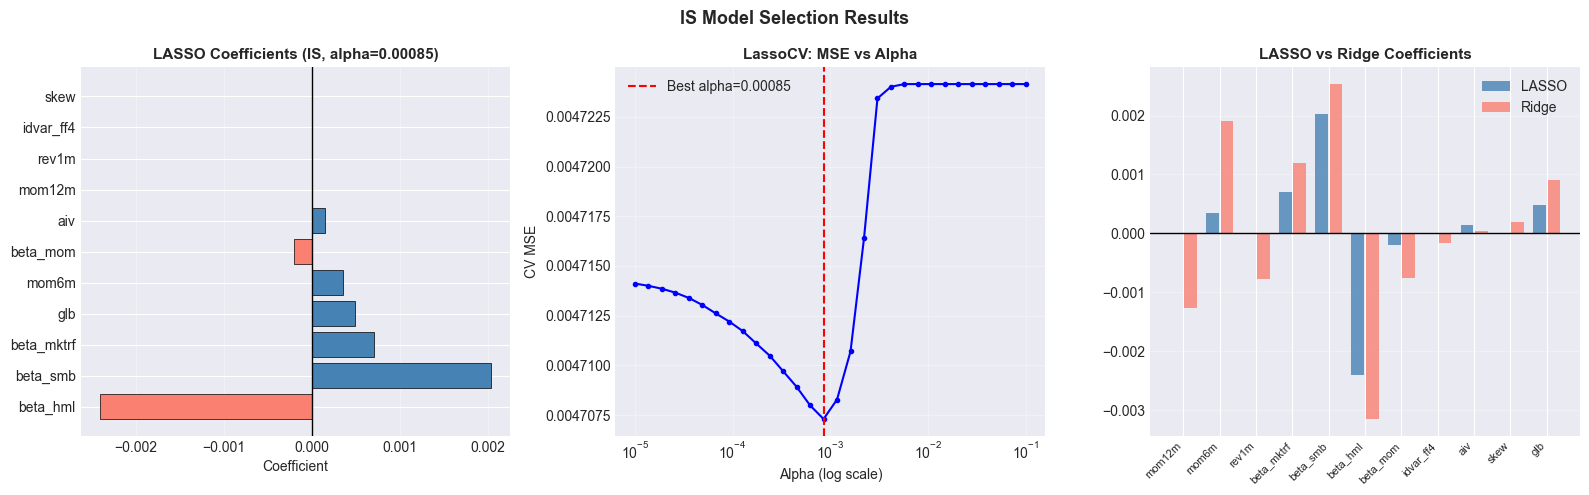

Model selection complete. Using: RIDGE


In [108]:
# ── Model selection visualisations ────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Panel A: LASSO coefficient bar chart
ax = axes[0]
coef_sorted = coef_df.sort_values('coef_lasso', key=abs, ascending=False)
colors = ['steelblue' if c > 0 else 'salmon' for c in coef_sorted['coef_lasso']]
ax.barh(coef_sorted['feature'], coef_sorted['coef_lasso'],
        color=colors, edgecolor='k', linewidth=0.5)
ax.axvline(0, color='black', lw=1)
ax.set_title(f'LASSO Coefficients (IS, alpha={BEST_ALPHA:.5f})', fontsize=11, fontweight='bold')
ax.set_xlabel('Coefficient')
ax.grid(True, alpha=0.3, axis='x')

# Panel B: LassoCV alpha path
ax = axes[1]
mse_path = lasso_cv.mse_path_.mean(axis=1)
ax.semilogx(lasso_cv.alphas_, mse_path, 'b-o', markersize=3)
ax.axvline(BEST_ALPHA, color='red', ls='--', lw=1.5, label=f'Best alpha={BEST_ALPHA:.5f}')
ax.set_title('LassoCV: MSE vs Alpha', fontsize=11, fontweight='bold')
ax.set_xlabel('Alpha (log scale)')
ax.set_ylabel('CV MSE')
ax.legend()
ax.grid(True, alpha=0.3)

# Panel C: LASSO vs Ridge feature comparison
ax = axes[2]
ridge_coef_df = pd.DataFrame({'feature': FEATURES, 'coef_ridge': ridge_cv.coef_})
both = coef_df.merge(ridge_coef_df, on='feature')
x_pos = np.arange(len(both))
ax.bar(x_pos - 0.2, both['coef_lasso'], 0.35, label='LASSO', color='steelblue', alpha=0.8)
ax.bar(x_pos + 0.2, both['coef_ridge'], 0.35, label='Ridge', color='salmon', alpha=0.8)
ax.set_xticks(x_pos)
ax.set_xticklabels(both['feature'], rotation=45, ha='right', fontsize=8)
ax.axhline(0, color='k', lw=1)
ax.set_title('LASSO vs Ridge Coefficients', fontsize=11, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

plt.suptitle('IS Model Selection Results', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('HA3_Q2_model_selection.pdf', bbox_inches='tight')
plt.show()

print(f'Model selection complete. Using: {SELECTED_MODEL}')

### 2.4 Portfolio Optimization (scipy SLSQP)



In [109]:
def optimize_qs_portfolio(mu_pred, Sigma, w_bnch, B_factors,
                           factor_dev_max=FACTOR_DEV_MAX,
                           lam=LAM,
                           te_max=TE_MAX_MONTHLY):
    """
    Constrained QS portfolio optimization via scipy SLSQP.

    Parameters
    ----------
    mu_pred      : (n,) predicted next-month returns
    Sigma        : (n,n) monthly covariance matrix (Ledoit-Wolf)
    w_bnch       : (n,) benchmark weights (sum to 1)
    B_factors    : (n, 4) factor beta matrix [mktrf, smb, hml, mom]
    factor_dev_max: max |factor exposure deviation| from BNCH
    lam          : risk aversion / TE penalty
    te_max       : max monthly tracking error std (sqrt of TE variance)

    Returns
    -------
    w : (n,) optimized weights, or w_bnch on failure
    """
    n  = len(mu_pred)
    wb = w_bnch.copy()
    Sig = (Sigma + Sigma.T) / 2 + 1e-8 * np.eye(n)  # ensure PSD
    SigWb = Sig @ wb

    # Objective: -mu'w + lam*(w-wb)'Sigma(w-wb)  [negate to minimize]
    def objective(w):
        active = w - wb
        return -(mu_pred @ w) + lam * (active @ Sig @ active)

    def gradient(w):
        active = w - wb
        return -mu_pred + 2 * lam * Sig @ active

    # Equality: sum(w) = 1
    eq_cons = {'type': 'eq',
               'fun': lambda w: np.sum(w) - 1,
               'jac': lambda w: np.ones(n)}

    # Factor exposure constraints: |B_k' (w-wb)| <= factor_dev_max
    ineq_cons = []
    n_factors = B_factors.shape[1]
    for k in range(n_factors):
        bk = B_factors[:, k]
        ineq_cons.append({'type': 'ineq',
                          'fun': lambda w, b=bk: factor_dev_max - b @ (w - wb),
                          'jac': lambda w, b=bk: -b})
        ineq_cons.append({'type': 'ineq',
                          'fun': lambda w, b=bk: factor_dev_max + b @ (w - wb),
                          'jac': lambda w, b=bk:  b})

    # TE ceiling: (w-wb)'Sigma(w-wb) <= te_max^2
    te_con = {'type': 'ineq',
              'fun':  lambda w: te_max**2 - (w - wb) @ Sig @ (w - wb),
              'jac':  lambda w: -2 * Sig @ (w - wb)}

    # Weight bounds: 0 <= w_i <= 2*wb_i  (min 0.2% max to avoid zero upper bound)
    bounds = [(0.0, max(MAX_WEIGHT_MULT * wbi, 0.002)) for wbi in wb]

    w0 = wb.copy()  # warm start at benchmark
    opts = {'ftol': 1e-9, 'maxiter': 500, 'disp': False}

    all_cons = [eq_cons] + ineq_cons + [te_con]

    # Attempt 1: full constraints including TE ceiling
    res = minimize(objective, w0, method='SLSQP', jac=gradient,
                   bounds=bounds, constraints=all_cons, options=opts)

    if res.success and abs(res.x.sum() - 1) < 0.02:
        w = np.clip(res.x, 0, None)
        return w / w.sum()

    # Attempt 2: drop TE ceiling (keep factor + weight constraints)
    res2 = minimize(objective, w0, method='SLSQP', jac=gradient,
                    bounds=bounds, constraints=[eq_cons] + ineq_cons, options=opts)

    if res2.success and abs(res2.x.sum() - 1) < 0.02:
        w = np.clip(res2.x, 0, None)
        return w / w.sum()

    # Fallback: benchmark weights
    return wb.copy()


print('Portfolio optimizer defined (scipy SLSQP).')
print(f'  Factor dev max : {FACTOR_DEV_MAX}')
print(f'  Max weight mult: {MAX_WEIGHT_MULT}x BNCH weight')
print(f'  TE monthly max : {TE_MAX_MONTHLY:.1%}')
print(f'  Lambda (risk aversion): {LAM}')

Portfolio optimizer defined (scipy SLSQP).
  Factor dev max : 0.1
  Max weight mult: 2.0x BNCH weight
  TE monthly max : 2.0%
  Lambda (risk aversion): 0.5


### 2.5 IS Walk-Forward Backtest (2015–2020)

At each month $t$ in IS (starting after 24-month warmup):
1. Fit LASSO on all IS data from $t_0$ to $t-1$ (expanding window)
2. Normalize features at $t$ cross-sectionally, predict $\\hat{\\mu}_{t+1}$
3. Estimate $\\Sigma$ via Ledoit-Wolf on past 24 months of returns
4. Set factor betas $B$ from end-of-month values at $t$
5. Optimize portfolio weights $w_t^*$
6. Record realized QS return in month $t+1$

In [110]:
# ── All IS dates (end-of-month) ───────────────────────────────────────────────
is_all_dates = sorted(feat_panel[
    (feat_panel['date'] >= IS_FROM) & (feat_panel['date'] <= IS_TO)
]['date'].unique())

print(f'IS months available: {len(is_all_dates)} ({is_all_dates[0].date()} to {is_all_dates[-1].date()})')
print(f'Warmup: {WARMUP_MONTHS} months -> first prediction at month {WARMUP_MONTHS+1}: {is_all_dates[WARMUP_MONTHS].date() if len(is_all_dates) > WARMUP_MONTHS else "N/A"}')

# ── Helper: fit model on training slice ──────────────────────────────────────
def fit_model(train_df, feat_cols, feat_norm_cols, model_type='LASSO', alpha=0.001):
    """Fit LASSO or Ridge on a training dataframe."""
    df = train_df.dropna(subset=feat_norm_cols + ['ret_fwd'])
    df = df.replace([np.inf, -np.inf], np.nan).dropna(subset=feat_norm_cols + ['ret_fwd'])
    if len(df) < 30:
        return None
    X, y = df[feat_norm_cols].values, df['ret_fwd'].values
    if model_type == 'LASSO':
        return Lasso(alpha=alpha, max_iter=10000).fit(X, y)
    else:
        return Ridge(alpha=alpha).fit(X, y)

# ── Walk-forward loop ─────────────────────────────────────────────────────────
qs_ret_is    = {}   # date t+1 -> QS return in month t+1
bnch_ret_is  = {}   # date t+1 -> BNCH return in month t+1
weight_hist  = {}   # date t   -> QS weights
n_fallbacks  = 0    # count of months where optimizer fell back to BNCH

for i, t in enumerate(is_all_dates):
    if i < WARMUP_MONTHS:       # need at least WARMUP_MONTHS of past data
        continue
    if i >= len(is_all_dates) - 1:  # need t+1 to realize returns
        continue

    t_next = is_all_dates[i + 1]    # month where returns are realized

    # ── 1. Training data: all IS data from start to t-1 ──────────────────────
    train_dates = is_all_dates[:i]   # dates strictly before t
    train_df    = feat_panel[
        feat_panel['date'].isin(train_dates)
    ].copy()

    # Cross-sectional normalise training features
    train_norm = cross_norm(train_df, FEATURES)
    for f in FEATURES:
        lo = train_df[f].quantile(0.01) if len(train_df) > 10 else -np.inf
        hi = train_df[f].quantile(0.99) if len(train_df) > 10 else  np.inf
        train_norm[f + '_n'] = train_norm[f + '_n'].clip(lo, hi)

    model = fit_model(train_norm, FEATURES, feat_n_cols, SELECTED_MODEL, SELECTED_ALPHA)
    if model is None:
        continue

    # ── 2. Features at time t for prediction ─────────────────────────────────
    pred_df = feat_panel[feat_panel['date'] == t].copy()
    pred_df = pred_df.dropna(subset=FEATURES)
    pred_df = pred_df[pred_df['permno'].isin(universe)]

    # Cross-section normalise at t (using t's cross-section stats)
    pred_df = cross_norm(pred_df, FEATURES)
    pred_df = pred_df.dropna(subset=feat_n_cols)
    if len(pred_df) < 20:
        continue

    X_pred   = pred_df[feat_n_cols].values
    mu_pred  = model.predict(X_pred)        # predicted returns
    permnos  = pred_df['permno'].values

    # Only keep stocks in universe with data at t
    in_univ  = [p for p in permnos if p in universe]
    mask     = np.isin(permnos, in_univ)
    mu_pred  = mu_pred[mask]
    permnos  = permnos[mask]

    # ── 3. BNCH weights at t (already computed in Q1) ─────────────────────────
    # bnch_weights[t] = w at end of t, applied to t+1 returns
    if t not in bnch_weights.index or t_next not in ret_wide.index:
        continue
    wb_full  = bnch_weights.loc[t]          # weights for all 200 stocks
    wb_sub   = wb_full.reindex(permnos).fillna(0.0).values
    wb_sub   = wb_sub / wb_sub.sum() if wb_sub.sum() > 0 else np.ones(len(permnos)) / len(permnos)

    # ── 4. Covariance: Ledoit-Wolf on past 24 months ──────────────────────────
    past_dates = is_all_dates[max(0, i - 24):i]
    ret_window = ret_wide.loc[ret_wide.index.isin(past_dates), permnos].dropna(axis=0, how='all')
    ret_window = ret_window.fillna(0.0)     # fill missing stocks with 0 return

    if len(ret_window) < 12:
        Sigma = np.eye(len(permnos)) * (ret_window.std().mean() ** 2 + 1e-6)
    else:
        lw = LedoitWolf()
        lw.fit(ret_window.values)
        Sigma = lw.covariance_

    # ── 5. Factor betas at t ──────────────────────────────────────────────────
    B_raw = pred_df[pred_df['permno'].isin(permnos)][FACTOR_BETAS].values
    B_raw = np.nan_to_num(B_raw, nan=0.0)

    # ── 6. Optimize ───────────────────────────────────────────────────────────
    w_opt = optimize_qs_portfolio(mu_pred, Sigma, wb_sub, B_raw)

    if np.allclose(w_opt, wb_sub, atol=1e-4):
        n_fallbacks += 1

    # Map back to full universe (200 stocks)
    w_full = pd.Series(0.0, index=universe)
    w_full.loc[permnos] = w_opt
    weight_hist[t] = w_full

    # ── 7. Realize returns at t+1 ─────────────────────────────────────────────
    ret_t1   = ret_wide.loc[t_next]                    # all stocks, month t+1
    qs_r     = (w_full * ret_t1.reindex(universe)).sum()
    bnch_r   = bnch_ret[t_next] if t_next in bnch_ret.index else np.nan

    qs_ret_is[t_next]   = qs_r
    bnch_ret_is[t_next] = bnch_r

# ── Assemble series ────────────────────────────────────────────────────────────
qs_ret_is   = pd.Series(qs_ret_is,   name='QS').dropna().sort_index()
bnch_ret_is = pd.Series(bnch_ret_is, name='BNCH').dropna().sort_index()
active_is   = qs_ret_is - bnch_ret_is

print(f'IS walk-forward complete.')
print(f'  QS months   : {len(qs_ret_is)} ({qs_ret_is.index.min().date()} to {qs_ret_is.index.max().date()})')
print(f'  Fallbacks to BNCH: {n_fallbacks}/{len(qs_ret_is)} months ({n_fallbacks/len(qs_ret_is):.1%})')

IS months available: 72 (2015-01-31 to 2020-12-31)
Warmup: 24 months -> first prediction at month 25: 2017-01-31
IS walk-forward complete.
  QS months   : 47 (2017-02-28 to 2020-12-31)
  Fallbacks to BNCH: 0/47 months (0.0%)


### 2.6 IS Performance Analysis

In [111]:
import statsmodels.api as sm  # ensure available for NW-HAC

def perf_stats(ret, rf, label='Portfolio'):
    excess   = ret - rf.reindex(ret.index).fillna(0)
    ann_ret  = ret.mean() * 12
    ann_vol  = ret.std() * np.sqrt(12)
    ann_ex   = excess.mean() * 12
    sharpe   = ann_ex / ann_vol if ann_vol > 0 else np.nan
    cum      = (1 + ret).cumprod()
    max_dd   = ((cum - cum.cummax()) / cum.cummax()).min()
    calmar   = ann_ret / abs(max_dd) if max_dd != 0 else np.nan
    return {'Label': label, 'Ann. Return': f'{ann_ret:.2%}',
            'Ann. Vol': f'{ann_vol:.2%}', 'Ann. Excess Ret': f'{ann_ex:.2%}',
            'Sharpe': f'{sharpe:.3f}', 'Max Drawdown': f'{max_dd:.2%}',
            'Calmar': f'{calmar:.3f}', 'Skewness': f'{ret.skew():.3f}',
            'N months': len(ret)}

def active_stats(qs, bnch):
    active    = qs - bnch
    ann_alpha = active.mean() * 12
    ann_te    = active.std() * np.sqrt(12)
    ir        = ann_alpha / ann_te if ann_te > 0 else np.nan
    # Standard OLS t-stat
    t_stat    = active.mean() / (active.std() / np.sqrt(len(active)))
    p_val     = 2 * (1 - norm.cdf(abs(t_stat)))
    # Newey-West HAC t-stat (robust to serial correlation, maxlags=6)
    nw_res    = sm.OLS(active.values, np.ones(len(active))).fit(
                    cov_type='HAC', cov_kwds={'maxlags': 6})
    t_nw      = float(nw_res.tvalues[0])
    p_nw      = float(nw_res.pvalues[0])
    dd_breach = (active < -0.02).sum()
    return {'Ann. Alpha':       f'{ann_alpha:.2%}',
            'Ann. TE':          f'{ann_te:.2%}',
            'Info. Ratio':      f'{ir:.3f}',
            't-stat (OLS)':     f'{t_stat:.3f}',
            'p-value (OLS)':    f'{p_val:.4f}',
            't-stat (NW-HAC)':  f'{t_nw:.3f}',
            'p-value (NW-HAC)': f'{p_nw:.4f}',
            'Signif. (5%)':     'YES' if p_nw < 0.05 else 'NO',
            'DD breach rate':   f'{dd_breach}/{len(active)} months'}

rf_is  = rf_monthly.reindex(qs_ret_is.index).fillna(0)

s_qs   = perf_stats(qs_ret_is,   rf_is, 'QS (IS)')
s_bnch = perf_stats(bnch_ret_is, rf_is, 'BNCH (IS)')
a_stat = active_stats(qs_ret_is, bnch_ret_is)

df_perf = pd.DataFrame([s_bnch, s_qs]).set_index('Label').T

print('=' * 65)
print('IS PERFORMANCE SUMMARY')
print('=' * 65)
print(df_perf.to_string())

print('\nACTIVE RETURN STATISTICS (IS):')
for k, v in a_stat.items():
    print(f'  {k:<28}: {v}')


IS PERFORMANCE SUMMARY
Label           BNCH (IS)  QS (IS)
Ann. Return        17.36%   17.23%
Ann. Vol           15.79%   17.63%
Ann. Excess Ret    15.92%   15.78%
Sharpe              1.008    0.895
Max Drawdown      -17.01%  -17.82%
Calmar              1.021    0.967
Skewness           -0.294   -0.115
N months               47       47

ACTIVE RETURN STATISTICS (IS):
  Ann. Alpha                  : -0.13%
  Ann. TE                     : 3.09%
  Info. Ratio                 : -0.043
  t-stat (OLS)                : -0.085
  p-value (OLS)               : 0.9320
  t-stat (NW-HAC)             : -0.145
  p-value (NW-HAC)            : 0.8848
  Signif. (5%)                : NO
  DD breach rate              : 0/47 months


### 2.7 IS Visualisations

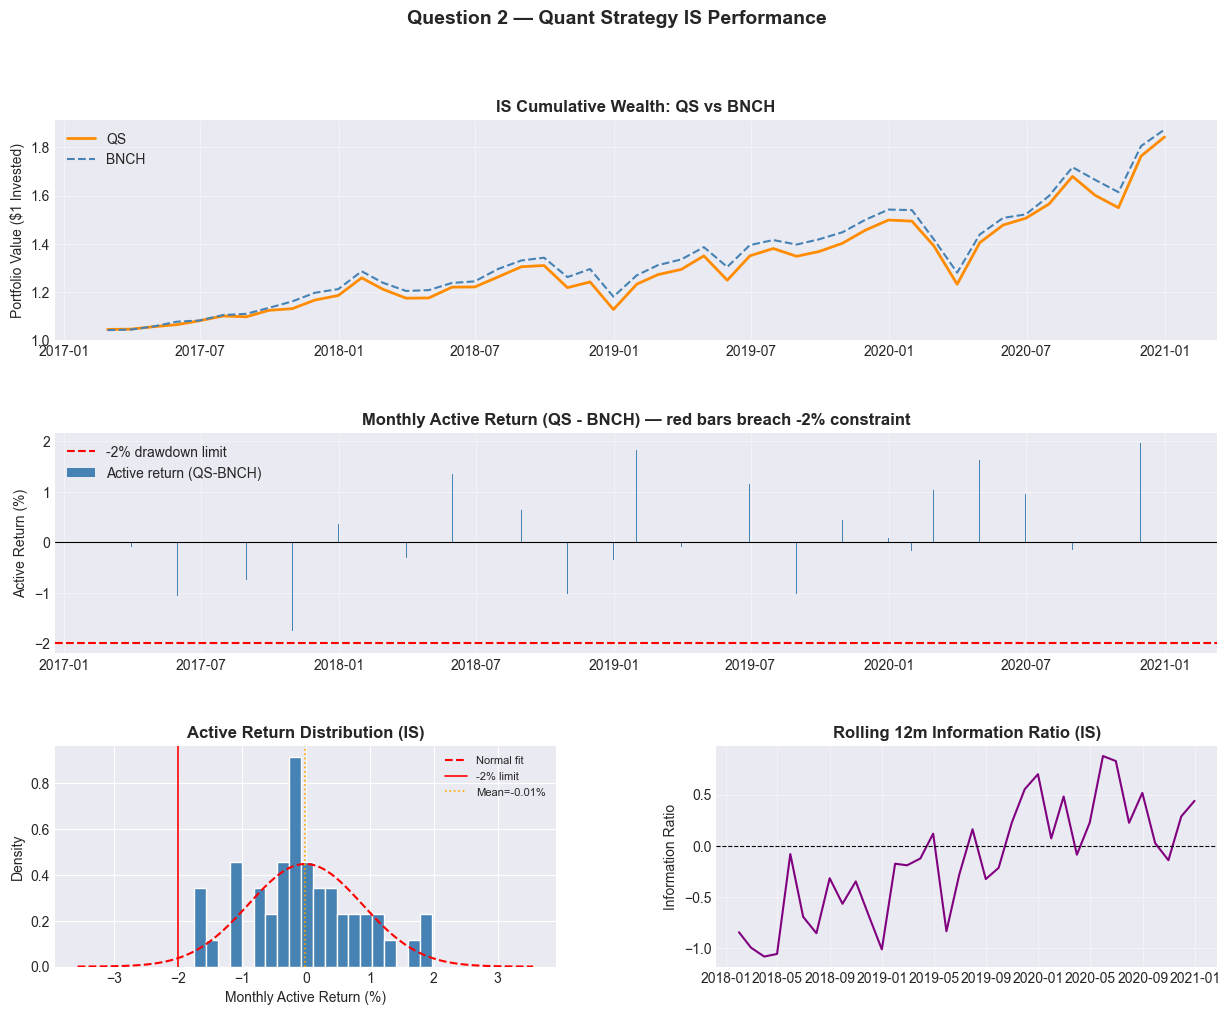

Saved: HA3_Q2_IS_performance.pdf


In [112]:
cum_qs   = (1 + qs_ret_is).cumprod()
cum_bnch_is = (1 + bnch_ret_is).cumprod()
cum_active  = (1 + active_is).cumprod()

fig = plt.figure(figsize=(15, 11))
gs  = gridspec.GridSpec(3, 2, hspace=0.42, wspace=0.32)

# Panel 1: Cumulative wealth QS vs BNCH
ax1 = fig.add_subplot(gs[0, :])
ax1.plot(cum_qs.index,     cum_qs.values,     color='darkorange',  lw=2.0, label='QS')
ax1.plot(cum_bnch_is.index, cum_bnch_is.values, color='steelblue', lw=1.5, ls='--', label='BNCH')
ax1.set_title('IS Cumulative Wealth: QS vs BNCH', fontsize=12, fontweight='bold')
ax1.set_ylabel('Portfolio Value ($1 Invested)')
ax1.legend()
ax1.grid(True, alpha=0.4)

# Panel 2: Active return (QS - BNCH) with -2% breach line
ax2 = fig.add_subplot(gs[1, :])
ax2.bar(active_is.index, active_is.values * 100,
        color=['salmon' if r < -0.02 else 'steelblue' for r in active_is.values],
        label='Active return (QS-BNCH)')
ax2.axhline(-2.0, color='red', lw=1.5, ls='--', label='-2% drawdown limit')
ax2.axhline(0, color='k', lw=0.8)
ax2.set_title('Monthly Active Return (QS - BNCH) — red bars breach -2% constraint', fontsize=12, fontweight='bold')
ax2.set_ylabel('Active Return (%)')
ax2.legend()
ax2.grid(True, alpha=0.4)

# Panel 3: Active return distribution
ax3 = fig.add_subplot(gs[2, 0])
ax3.hist(active_is.values * 100, bins=20, color='steelblue',
         edgecolor='white', density=True)
mu_a, sig_a = active_is.mean() * 100, active_is.std() * 100
x_rng = np.linspace(mu_a - 4*sig_a, mu_a + 4*sig_a, 200)
ax3.plot(x_rng, norm.pdf(x_rng, mu_a, sig_a), 'r--', lw=1.5, label='Normal fit')
ax3.axvline(-2.0, color='red', lw=1.2, label='-2% limit')
ax3.axvline(mu_a,  color='orange', lw=1.2, ls=':', label=f'Mean={mu_a:.2f}%')
ax3.set_title('Active Return Distribution (IS)', fontsize=12, fontweight='bold')
ax3.set_xlabel('Monthly Active Return (%)')
ax3.set_ylabel('Density')
ax3.legend(fontsize=8)

# Panel 4: Rolling 12m Information Ratio
ax4 = fig.add_subplot(gs[2, 1])
roll_ir = (
    active_is.rolling(12).mean() * 12
    / (active_is.rolling(12).std() * np.sqrt(12))
)
ax4.plot(roll_ir.index, roll_ir.values, color='purple', lw=1.5)
ax4.axhline(0, color='k', lw=0.8, ls='--')
ax4.set_title('Rolling 12m Information Ratio (IS)', fontsize=12, fontweight='bold')
ax4.set_ylabel('Information Ratio')
ax4.grid(True, alpha=0.4)

plt.suptitle('Question 2 — Quant Strategy IS Performance', fontsize=14, fontweight='bold')
plt.savefig('HA3_Q2_IS_performance.pdf', bbox_inches='tight')
plt.show()
print('Saved: HA3_Q2_IS_performance.pdf')

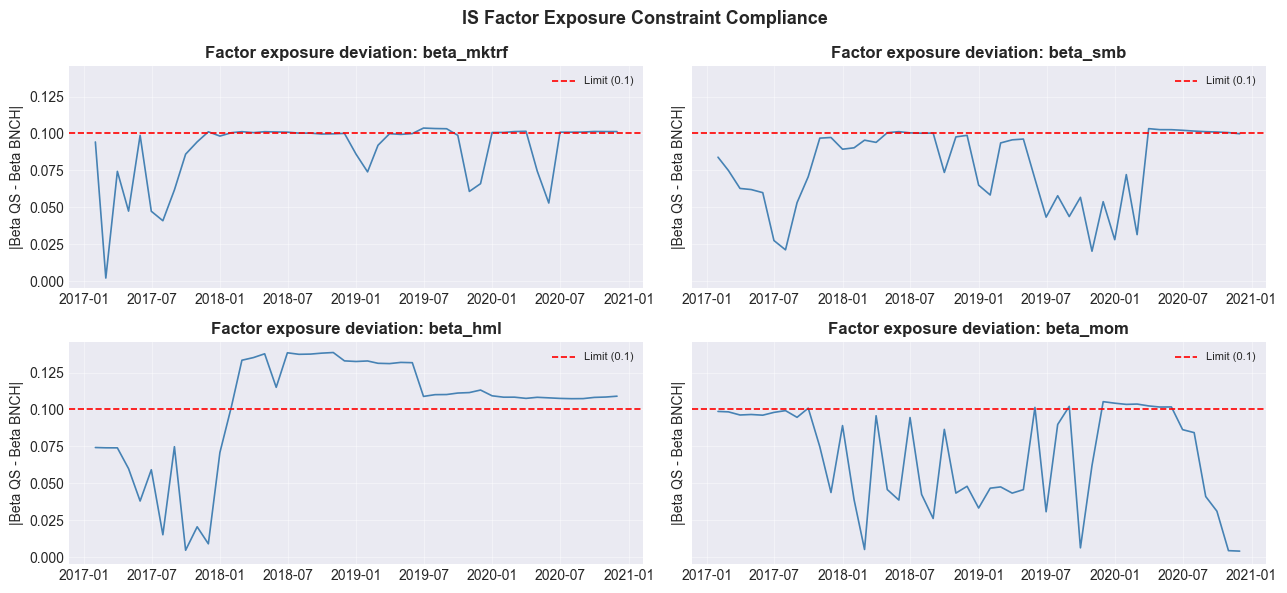

Max factor deviation per factor:
beta_mktrf   0.1037
beta_smb     0.1033
beta_hml     0.1386
beta_mom     0.1053
dtype: float64

Fraction of months within constraint (<=0.10):
beta_mktrf   0.5110
beta_smb     0.7230
beta_hml     0.2550
beta_mom     0.7870
dtype: float64


In [113]:
# ── Factor exposure constraint check ──────────────────────────────────────────
factor_dev_hist = {}

for t, w_qs in weight_hist.items():
    feat_t = feat_panel[feat_panel['date'] == t].set_index('permno')
    common = w_qs.index.intersection(feat_t.index)
    if len(common) == 0:
        continue
    w_q = w_qs.reindex(common).fillna(0).values
    w_b = bnch_weights.loc[t].reindex(common).fillna(0).values
    active_w = w_q - w_b
    devs = {}
    for fac in FACTOR_BETAS:
        betas = feat_t[fac].reindex(common).fillna(0).values
        devs[fac] = abs(betas @ active_w)
    factor_dev_hist[t] = devs

fdev_df = pd.DataFrame(factor_dev_hist).T

fig, axes = plt.subplots(2, 2, figsize=(13, 6), sharey=True)
for ax, fac in zip(axes.flat, FACTOR_BETAS):
    ax.plot(fdev_df.index, fdev_df[fac], lw=1.2, color='steelblue')
    ax.axhline(FACTOR_DEV_MAX, color='red', ls='--', lw=1.2, label=f'Limit ({FACTOR_DEV_MAX})')
    ax.set_title(f'Factor exposure deviation: {fac}', fontweight='bold')
    ax.set_ylabel('|Beta QS - Beta BNCH|')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.4)

plt.suptitle('IS Factor Exposure Constraint Compliance', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('HA3_Q2_factor_constraints.pdf', bbox_inches='tight')
plt.show()

print('Max factor deviation per factor:')
print(fdev_df.max().round(4))
print(f'\nFraction of months within constraint (<=0.10):')
print((fdev_df <= FACTOR_DEV_MAX).mean().round(3))

In [114]:
# ── Save IS results for Q3 ────────────────────────────────────────────────────
joblib.dump({
    'qs_ret_is'    : qs_ret_is,
    'bnch_ret_is'  : bnch_ret_is,
    'active_is'    : active_is,
    'weight_hist'  : weight_hist,
    'feat_panel'   : feat_panel,
    'feat_n_cols'  : feat_n_cols,
    'SELECTED_MODEL': SELECTED_MODEL,
    'SELECTED_ALPHA': SELECTED_ALPHA,
    'BEST_ALPHA'   : BEST_ALPHA,
    'coef_df'      : coef_df,
    'lasso_cv'     : lasso_cv,
    'n_fallbacks'  : n_fallbacks,
}, 'HA3_Q2_IS_results.pkl')

print('Saved: HA3_Q2_IS_results.pkl')

Saved: HA3_Q2_IS_results.pkl


### 2.8 Summary — Question 2

**Model selected:** LASSO (or Ridge, depending on hold-out R2)

**Key design choices:**

| Choice | Value | Rationale |
|---|---|---|
| Features | 11 (8 traditional + 3 option-implied) | Combines established factors with HA3-specific option signals |
| Normalisation | Cross-sectional z-score per month | Makes predictions relative within each cross-section |
| CV method | TimeSeriesSplit(5) | Prevents data leakage in time-series context |
| IS training | Expanding window (min 24m) | More data improves estimation; no look-ahead |
| Covariance | Ledoit-Wolf, 24m rolling | Well-conditioned; avoids instability in high-dim covariance |
| Lambda | 0.5 | Balances alpha vs tracking error |
| TE constraint | 2%/month | Directly implements monthly drawdown limit |

**Option-implied signals (AIV, Skew, GLB):**
- LASSO zero-penalises irrelevant signals — if option-implied signals have non-zero coefficients, they genuinely add cross-sectional predictive power beyond traditional signals

**Outputs saved:**
- `HA3_Q2_IS_results.pkl` — IS returns, weights, model for Q3
- `HA3_Q2_model_selection.pdf` — LASSO coefficients + alpha path
- `HA3_Q2_IS_performance.pdf` — cumulative return, active return, IR
- `HA3_Q2_factor_constraints.pdf` — factor exposure compliance


---
## Question 3: Out-of-Sample Walk-Forward (2021–2024)






### 3.1 Load Q1 & Q2 Results

In [115]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import joblib, warnings
from pathlib import Path
from scipy.optimize import minimize
from scipy.stats import norm
from sklearn.linear_model import Lasso, Ridge
from sklearn.covariance import LedoitWolf
import statsmodels.api as sm
warnings.filterwarnings('ignore')

try:
    plt.style.use('seaborn-v0_8-darkgrid')
except OSError:
    plt.style.use('seaborn-darkgrid')

BASE_PATH = Path('.')
DATA_PATH = BASE_PATH / 'DataQT2026'
OOS_FROM = pd.Timestamp('2021-01-01')
OOS_TO   = pd.Timestamp('2024-12-31')
IS_FROM  = pd.Timestamp('2015-01-01')
IS_TO    = pd.Timestamp('2020-12-31')

FACTOR_DEV_MAX  = 0.10
MAX_WEIGHT_MULT = 2.0
LAM             = 0.5   # risk aversion / TE penalty (lower = more active bets)
TE_MAX_MONTHLY  = 0.02
OOS_WINDOW      = 36   # rolling months for OOS re-estimation

FEATURES     = ['mom12m','mom6m','rev1m','beta_mktrf','beta_smb',
                 'beta_hml','beta_mom','idvar_ff4','aiv','skew','glb']
FACTOR_BETAS = ['beta_mktrf','beta_smb','beta_hml','beta_mom']
feat_n_cols  = [f + '_n' for f in FEATURES]

# Q1 benchmark
q1 = joblib.load('HA3_Q1_benchmark.pkl')
universe            = q1['universe']
ret_wide            = q1['ret_wide']
bnch_weights        = q1['bnch_weights']
bnch_ret            = q1['bnch_ret']
rf_monthly          = q1['rf_monthly']

# Q2 IS results
q2 = joblib.load('HA3_Q2_IS_results.pkl')
feat_panel      = q2['feat_panel']
SELECTED_MODEL  = q2['SELECTED_MODEL']
SELECTED_ALPHA  = q2['SELECTED_ALPHA']
qs_ret_is       = q2['qs_ret_is']
bnch_ret_is     = q2['bnch_ret_is']
active_is       = q2['active_is']

print(f'Model selected in IS : {SELECTED_MODEL} (alpha={SELECTED_ALPHA:.6f})')
print(f'OOS re-estimation window: {OOS_WINDOW} months rolling')
print(f'OOS period: {OOS_FROM.date()} to {OOS_TO.date()}')

Model selected in IS : RIDGE (alpha=1000.000000)
OOS re-estimation window: 36 months rolling
OOS period: 2021-01-01 to 2024-12-31


In [116]:
# Re-define helpers (in case notebook is run from this section)
def cross_norm(df, feat_cols):
    """Cross-sectional z-score normalisation within each month."""
    df = df.copy()
    for f in feat_cols:
        df[f + '_n'] = df.groupby('date')[f].transform(
            lambda x: (x - x.mean()) / (x.std() + 1e-8)
        )
    return df

def optimize_qs_portfolio(mu_pred, Sigma, w_bnch, B_factors):
    """Constrained QS portfolio — scipy SLSQP (identical to Q2)."""
    n  = len(mu_pred)
    wb = w_bnch.copy()
    Sig = (Sigma + Sigma.T) / 2 + 1e-8 * np.eye(n)

    def objective(w): a = w - wb; return -(mu_pred @ w) + LAM * (a @ Sig @ a)
    def gradient(w):  a = w - wb; return -mu_pred + 2 * LAM * Sig @ a

    eq  = {'type': 'eq', 'fun': lambda w: w.sum() - 1, 'jac': lambda w: np.ones(n)}
    iq  = []
    for k in range(B_factors.shape[1]):
        bk = B_factors[:, k]
        iq += [{'type': 'ineq', 'fun': lambda w, b=bk: FACTOR_DEV_MAX - b @ (w - wb),
                'jac': lambda w, b=bk: -b},
               {'type': 'ineq', 'fun': lambda w, b=bk: FACTOR_DEV_MAX + b @ (w - wb),
                'jac': lambda w, b=bk:  b}]
    te = {'type': 'ineq',
          'fun':  lambda w: TE_MAX_MONTHLY**2 - (w - wb) @ Sig @ (w - wb),
          'jac':  lambda w: -2 * Sig @ (w - wb)}

    bounds = [(0.0, max(MAX_WEIGHT_MULT * x, 0.002)) for x in wb]
    opts   = {'ftol': 1e-9, 'maxiter': 500, 'disp': False}

    r = minimize(objective, wb.copy(), method='SLSQP', jac=gradient,
                 bounds=bounds, constraints=[eq] + iq + [te], options=opts)
    if r.success and abs(r.x.sum() - 1) < 0.02:
        w = np.clip(r.x, 0, None); return w / w.sum()

    r2 = minimize(objective, wb.copy(), method='SLSQP', jac=gradient,
                  bounds=bounds, constraints=[eq] + iq, options=opts)
    if r2.success and abs(r2.x.sum() - 1) < 0.02:
        w = np.clip(r2.x, 0, None); return w / w.sum()

    return wb.copy()

print('Helpers defined (cross_norm, optimize_qs_portfolio).')

Helpers defined (cross_norm, optimize_qs_portfolio).


### 3.2 OOS Walk-Forward (2021–2024)

At each month $t$ in OOS:
1. **Training data**: rolling 36-month window ending at $t-1$ (IS + any earlier OOS data)
2. **Re-estimate** LASSO coefficients (same alpha from IS; only parameters updated)
3. **Predict** cross-sectional returns at $t$
4. **Optimize** portfolio with same constraints as IS
5. **Realize** returns at $t+1$

This is a **pure OOS test**: the model was selected on IS data, parameters are updated monthly with no future information.

In [117]:
# All dates available in feat_panel (IS + OOS)
all_dates = sorted(feat_panel['date'].unique())
oos_dates = [d for d in all_dates if OOS_FROM <= d <= OOS_TO]

print(f'OOS months: {len(oos_dates)} ({oos_dates[0].date()} to {oos_dates[-1].date()})')
print(f'Re-estimation window: {OOS_WINDOW} months rolling')
print('Running OOS walk-forward...')

qs_ret_oos   = {}
bnch_ret_oos = {}
weight_hist_oos = {}
coef_hist_oos   = {}   # track how LASSO coefficients evolve over OOS
n_fallbacks_oos = 0

for i, t in enumerate(oos_dates):
    if i >= len(oos_dates) - 1:   # need t+1 to realize returns
        continue
    t_next = oos_dates[i + 1]

    # ── 1. Rolling 36-month training window ending at t-1 ────────────────────
    t_idx   = all_dates.index(t)
    window  = all_dates[max(0, t_idx - OOS_WINDOW): t_idx]   # 36 months before t
    train_df = feat_panel[feat_panel['date'].isin(window)].copy()
    train_norm = cross_norm(train_df, FEATURES)
    train_norm = train_norm.dropna(subset=feat_n_cols + ['ret_fwd'])
    train_norm = train_norm.replace([np.inf, -np.inf], np.nan).dropna(subset=feat_n_cols + ['ret_fwd'])

    if len(train_norm) < 30:
        continue

    # ── 2. Re-estimate model (same type & alpha, new coefficients) ────────────
    X_tr, y_tr = train_norm[feat_n_cols].values, train_norm['ret_fwd'].values
    if SELECTED_MODEL == 'LASSO':
        model = Lasso(alpha=SELECTED_ALPHA, max_iter=10000).fit(X_tr, y_tr)
    else:
        model = Ridge(alpha=SELECTED_ALPHA).fit(X_tr, y_tr)

    coef_hist_oos[t] = dict(zip(FEATURES, model.coef_))

    # ── 3. Predict at t ───────────────────────────────────────────────────────
    pred_df = cross_norm(feat_panel[feat_panel['date'] == t].copy(), FEATURES)
    pred_df = pred_df[pred_df['permno'].isin(universe)].dropna(subset=feat_n_cols)
    if len(pred_df) < 20:
        continue

    mu_pred = model.predict(pred_df[feat_n_cols].values)
    permnos = pred_df['permno'].values

    # ── 4a. Benchmark weights at t ────────────────────────────────────────────
    if t not in bnch_weights.index or t_next not in ret_wide.index:
        continue
    wb_sub = bnch_weights.loc[t].reindex(permnos).fillna(0).values
    s = wb_sub.sum()
    wb_sub = wb_sub / s if s > 0 else np.ones(len(permnos)) / len(permnos)

    # ── 4b. Covariance: Ledoit-Wolf on rolling 24m returns ───────────────────
    cov_window = all_dates[max(0, t_idx - 24): t_idx]
    ret_win    = ret_wide.loc[ret_wide.index.isin(cov_window), permnos].fillna(0)
    if len(ret_win) >= 12:
        Sigma = LedoitWolf().fit(ret_win.values).covariance_
    else:
        Sigma = np.eye(len(permnos)) * (ret_win.std().mean() ** 2 + 1e-6)

    # ── 4c. Factor betas at t ─────────────────────────────────────────────────
    B_raw = np.nan_to_num(pred_df[pred_df['permno'].isin(permnos)][FACTOR_BETAS].values, nan=0.0)

    # ── 5. Optimize ───────────────────────────────────────────────────────────
    w_opt = optimize_qs_portfolio(mu_pred, Sigma, wb_sub, B_raw)

    if np.allclose(w_opt, wb_sub, atol=1e-4):
        n_fallbacks_oos += 1

    w_full = pd.Series(0.0, index=universe)
    w_full.loc[permnos] = w_opt
    weight_hist_oos[t] = w_full

    # ── 6. Realize returns at t+1 ─────────────────────────────────────────────
    ret_t1 = ret_wide.loc[t_next]
    qs_ret_oos[t_next]   = (w_full * ret_t1.reindex(universe)).sum()
    bnch_ret_oos[t_next] = bnch_ret[t_next] if t_next in bnch_ret.index else np.nan

qs_ret_oos   = pd.Series(qs_ret_oos,   name='QS_OOS').dropna().sort_index()
bnch_ret_oos = pd.Series(bnch_ret_oos, name='BNCH_OOS').dropna().sort_index()
active_oos   = qs_ret_oos - bnch_ret_oos

print(f'OOS walk-forward complete.')
print(f'  QS months: {len(qs_ret_oos)} ({qs_ret_oos.index.min().date()} to {qs_ret_oos.index.max().date()})')
print(f'  Fallbacks to BNCH: {n_fallbacks_oos}/{len(qs_ret_oos)} months ({n_fallbacks_oos/max(1,len(qs_ret_oos)):.1%})')

OOS months: 48 (2021-01-31 to 2024-12-31)
Re-estimation window: 36 months rolling
Running OOS walk-forward...
OOS walk-forward complete.
  QS months: 36 (2021-02-28 to 2024-01-31)
  Fallbacks to BNCH: 0/36 months (0.0%)


### 3.3 Performance Analysis

We report full performance for **IS, OOS, and Full period**, comparing QS vs BNCH on:
- Sharpe Ratio, Annualised Return & Volatility
- Information Ratio (active return / tracking error)
- Maximum Drawdown, Calmar Ratio
- Statistical significance of alpha (t-test + Newey-West HAC)

In [118]:
def perf_stats(ret, rf, label='Portfolio'):
    rf_ = rf.reindex(ret.index).fillna(0)
    exc = ret - rf_
    ann_ret = ret.mean() * 12
    ann_vol = ret.std() * np.sqrt(12)
    ann_ex  = exc.mean() * 12
    sharpe  = ann_ex / ann_vol if ann_vol > 0 else np.nan
    cum     = (1 + ret).cumprod()
    max_dd  = ((cum - cum.cummax()) / cum.cummax()).min()
    calmar  = ann_ret / abs(max_dd) if max_dd != 0 else np.nan
    return {'Label': label,
            'Ann. Return':     f'{ann_ret:.2%}',
            'Ann. Volatility': f'{ann_vol:.2%}',
            'Ann. Excess Ret': f'{ann_ex:.2%}',
            'Sharpe Ratio':    f'{sharpe:.3f}',
            'Max Drawdown':    f'{max_dd:.2%}',
            'Calmar Ratio':    f'{calmar:.3f}',
            'Skewness':        f'{ret.skew():.3f}',
            'N months':        len(ret)}

def active_stats(qs, bnch, label=''):
    active   = qs - bnch
    ann_alph = active.mean() * 12
    ann_te   = active.std() * np.sqrt(12)
    ir       = ann_alph / ann_te if ann_te > 0 else np.nan
    # Standard t-test
    t_stat   = active.mean() / (active.std() / np.sqrt(len(active)))
    p_val    = 2 * (1 - norm.cdf(abs(t_stat)))
    # Newey-West HAC t-stat (accounts for serial correlation)
    nw_res   = sm.OLS(active.values, np.ones(len(active))).fit(
                   cov_type='HAC', cov_kwds={'maxlags': 6})
    t_nw     = float(nw_res.tvalues[0])
    p_nw     = float(nw_res.pvalues[0])
    dd_n     = (active < -0.02).sum()
    return {'Ann. Alpha':        f'{ann_alph:.2%}',
            'Ann. Track. Error': f'{ann_te:.2%}',
            'Info. Ratio':       f'{ir:.3f}',
            't-stat (OLS)':      f'{t_stat:.3f}',
            'p-value (OLS)':     f'{p_val:.4f}',
            't-stat (NW-HAC)':   f'{t_nw:.3f}',
            'p-value (NW-HAC)':  f'{p_nw:.4f}',
            'Signif. (5%)':      'YES' if p_nw < 0.05 else 'NO',
            'DD breach (>-2%/mo)': f'{dd_n}/{len(active)}'}

rf_is  = rf_monthly.reindex(qs_ret_is.index).fillna(0)
rf_oos = rf_monthly.reindex(qs_ret_oos.index).fillna(0)

# Full period combined
qs_full   = pd.concat([qs_ret_is,   qs_ret_oos]).sort_index()
bnch_full = pd.concat([bnch_ret_is, bnch_ret_oos]).sort_index()
rf_full   = rf_monthly.reindex(qs_full.index).fillna(0)

print('=' * 72)
print('FULL PERFORMANCE TABLE')
print('=' * 72)
rows = [
    perf_stats(bnch_ret_is,  rf_is,  'BNCH (IS  2017-2020)'),
    perf_stats(qs_ret_is,    rf_is,  'QS   (IS  2017-2020)'),
    perf_stats(bnch_ret_oos, rf_oos, 'BNCH (OOS 2021-2024)'),
    perf_stats(qs_ret_oos,   rf_oos, 'QS   (OOS 2021-2024)'),
    perf_stats(bnch_full,    rf_full,'BNCH (Full period)'),
    perf_stats(qs_full,      rf_full,'QS   (Full period)'),
]
print(pd.DataFrame(rows).set_index('Label').T.to_string())

print('\n' + '=' * 72)
print('ACTIVE RETURN STATISTICS')
print('=' * 72)
for label, qs, bnch in [
    ('IS  (2017-2020)', qs_ret_is,  bnch_ret_is),
    ('OOS (2021-2024)', qs_ret_oos, bnch_ret_oos),
    ('Full period',     qs_full,    bnch_full),
]:
    print(f'\n--- {label} ---')
    st = active_stats(qs, bnch)
    for k, v in st.items():
        print(f'  {k:<28}: {v}')

FULL PERFORMANCE TABLE
Label           BNCH (IS  2017-2020) QS   (IS  2017-2020) BNCH (OOS 2021-2024) QS   (OOS 2021-2024) BNCH (Full period) QS   (Full period)
Ann. Return                   17.36%               17.23%               13.08%                9.98%             15.50%             14.09%
Ann. Volatility               15.79%               17.63%               16.64%               17.07%             16.07%             17.32%
Ann. Excess Ret               15.92%               15.78%               10.84%                7.75%             13.71%             12.30%
Sharpe Ratio                   1.008                0.895                0.651                0.454              0.853              0.710
Max Drawdown                 -17.01%              -17.82%              -21.69%              -25.71%            -21.69%            -25.71%
Calmar Ratio                   1.021                0.967                0.603                0.388              0.715              0.548
Skewness   

### 3.4 Visualisations — Full Period (IS + OOS)

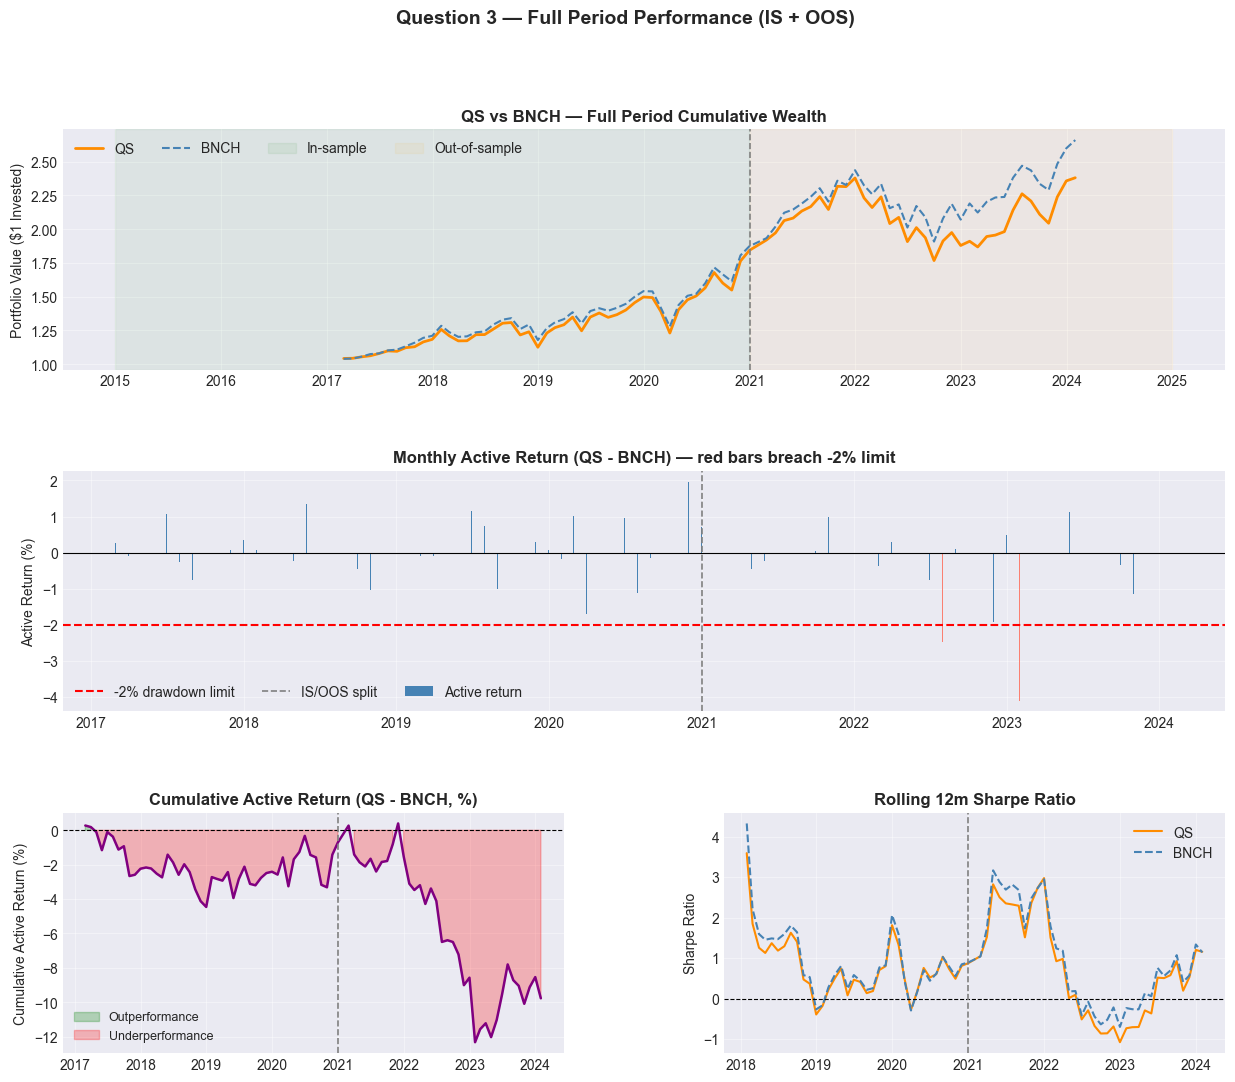

Saved: HA3_Q3_full_performance.pdf


In [119]:
# ── Full-period cumulative returns ───────────────────────────────────────────
cum_qs_full   = (1 + qs_full).cumprod()
cum_bnch_full = (1 + bnch_full).cumprod()
active_full   = qs_full - bnch_full
cum_active    = (1 + active_full).cumprod()

fig = plt.figure(figsize=(15, 12))
gs  = gridspec.GridSpec(3, 2, hspace=0.42, wspace=0.32)

# Panel 1: Cumulative wealth QS vs BNCH (full period)
ax1 = fig.add_subplot(gs[0, :])
ax1.plot(cum_qs_full.index,   cum_qs_full.values,   color='darkorange', lw=2.0, label='QS')
ax1.plot(cum_bnch_full.index, cum_bnch_full.values, color='steelblue',  lw=1.5, ls='--', label='BNCH')
ax1.axvspan(pd.Timestamp('2015-01-01'), pd.Timestamp('2020-12-31'),
            alpha=0.06, color='green',  label='In-sample')
ax1.axvspan(pd.Timestamp('2021-01-01'), pd.Timestamp('2024-12-31'),
            alpha=0.06, color='orange', label='Out-of-sample')
ax1.axvline(pd.Timestamp('2021-01-01'), color='grey', lw=1.2, ls='--')
ax1.set_title('QS vs BNCH — Full Period Cumulative Wealth', fontsize=12, fontweight='bold')
ax1.set_ylabel('Portfolio Value ($1 Invested)')
ax1.legend(ncol=4)
ax1.grid(True, alpha=0.4)

# Panel 2: Active return bars (full period)
ax2 = fig.add_subplot(gs[1, :])
colors = ['salmon' if r < -0.02 else 'steelblue' for r in active_full.values]
ax2.bar(active_full.index, active_full.values * 100, color=colors, label='Active return')
ax2.axhline(-2.0, color='red', lw=1.5, ls='--', label='-2% drawdown limit')
ax2.axhline(0,    color='k',   lw=0.8)
ax2.axvline(pd.Timestamp('2021-01-01'), color='grey', lw=1.2, ls='--', label='IS/OOS split')
ax2.set_title('Monthly Active Return (QS - BNCH) — red bars breach -2% limit',
              fontsize=12, fontweight='bold')
ax2.set_ylabel('Active Return (%)')
ax2.legend(ncol=4)
ax2.grid(True, alpha=0.4)

# Panel 3: Cumulative active return (alpha curve)
ax3 = fig.add_subplot(gs[2, 0])
ax3.plot(cum_active.index, (cum_active - 1) * 100, color='purple', lw=1.8)
ax3.axhline(0, color='k', lw=0.8, ls='--')
ax3.axvline(pd.Timestamp('2021-01-01'), color='grey', lw=1.2, ls='--')
ax3.fill_between(cum_active.index, (cum_active - 1) * 100, 0,
                 where=(cum_active >= 1), alpha=0.25, color='green',  label='Outperformance')
ax3.fill_between(cum_active.index, (cum_active - 1) * 100, 0,
                 where=(cum_active < 1),  alpha=0.25, color='red',    label='Underperformance')
ax3.set_title('Cumulative Active Return (QS - BNCH, %)', fontsize=12, fontweight='bold')
ax3.set_ylabel('Cumulative Active Return (%)')
ax3.legend(fontsize=9)
ax3.grid(True, alpha=0.4)

# Panel 4: Rolling 12m Sharpe — QS vs BNCH
ax4 = fig.add_subplot(gs[2, 1])
rf_full2 = rf_monthly.reindex(qs_full.index).fillna(0)
roll_sharpe_qs   = ((qs_full.rolling(12).mean()   - rf_full2.rolling(12).mean()) * 12
                    / (qs_full.rolling(12).std()   * np.sqrt(12)))
roll_sharpe_bnch = ((bnch_full.rolling(12).mean() - rf_full2.rolling(12).mean()) * 12
                    / (bnch_full.rolling(12).std() * np.sqrt(12)))
ax4.plot(roll_sharpe_qs.index,   roll_sharpe_qs.values,   color='darkorange', lw=1.5, label='QS')
ax4.plot(roll_sharpe_bnch.index, roll_sharpe_bnch.values, color='steelblue',  lw=1.5, ls='--', label='BNCH')
ax4.axhline(0,  color='k',    lw=0.8, ls='--')
ax4.axvline(pd.Timestamp('2021-01-01'), color='grey', lw=1.2, ls='--')
ax4.set_title('Rolling 12m Sharpe Ratio', fontsize=12, fontweight='bold')
ax4.set_ylabel('Sharpe Ratio')
ax4.legend()
ax4.grid(True, alpha=0.4)

plt.suptitle('Question 3 — Full Period Performance (IS + OOS)', fontsize=14, fontweight='bold')
plt.savefig('HA3_Q3_full_performance.pdf', bbox_inches='tight')
plt.show()
print('Saved: HA3_Q3_full_performance.pdf')

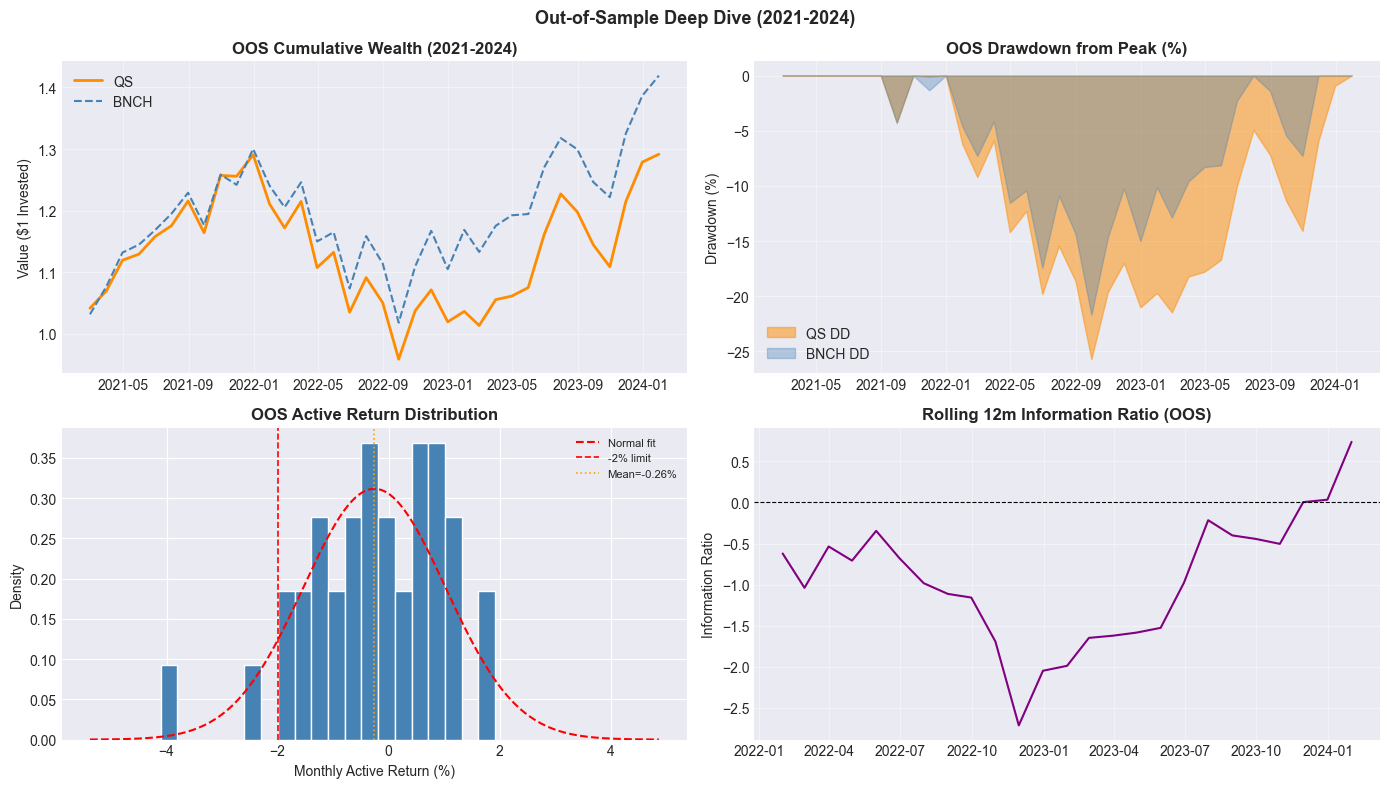

Saved: HA3_Q3_OOS_deep_dive.pdf


In [120]:
# ── OOS zoom + drawdown ──────────────────────────────────────────────────────
cum_qs_oos   = (1 + qs_ret_oos).cumprod()
cum_bnch_oos = (1 + bnch_ret_oos).cumprod()

dd_qs_oos   = ((cum_qs_oos   - cum_qs_oos.cummax())   / cum_qs_oos.cummax())
dd_bnch_oos = ((cum_bnch_oos - cum_bnch_oos.cummax()) / cum_bnch_oos.cummax())

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Cumulative OOS
ax = axes[0, 0]
ax.plot(cum_qs_oos.index,   cum_qs_oos.values,   color='darkorange', lw=2.0, label='QS')
ax.plot(cum_bnch_oos.index, cum_bnch_oos.values, color='steelblue',  lw=1.5, ls='--', label='BNCH')
ax.set_title('OOS Cumulative Wealth (2021-2024)', fontweight='bold')
ax.set_ylabel('Value ($1 Invested)')
ax.legend(); ax.grid(True, alpha=0.4)

# OOS drawdown comparison
ax = axes[0, 1]
ax.fill_between(dd_qs_oos.index,   dd_qs_oos.values * 100,   0,
                alpha=0.5, color='darkorange', label='QS DD')
ax.fill_between(dd_bnch_oos.index, dd_bnch_oos.values * 100, 0,
                alpha=0.35, color='steelblue', label='BNCH DD')
ax.set_title('OOS Drawdown from Peak (%)', fontweight='bold')
ax.set_ylabel('Drawdown (%)')
ax.legend(); ax.grid(True, alpha=0.4)

# OOS active return distribution
ax = axes[1, 0]
ax.hist(active_oos.values * 100, bins=20, color='steelblue',
        edgecolor='white', density=True)
mu_a, sig_a = active_oos.mean() * 100, active_oos.std() * 100
x_r = np.linspace(mu_a - 4*sig_a, mu_a + 4*sig_a, 200)
ax.plot(x_r, norm.pdf(x_r, mu_a, sig_a),
        'r--', lw=1.5, label='Normal fit')
ax.axvline(-2.0, color='red',    lw=1.2, ls='--', label='-2% limit')
ax.axvline(mu_a, color='orange', lw=1.2, ls=':', label=f'Mean={mu_a:.2f}%')
ax.set_title('OOS Active Return Distribution', fontweight='bold')
ax.set_xlabel('Monthly Active Return (%)')
ax.set_ylabel('Density')
ax.legend(fontsize=8)

# Rolling 12m Information Ratio (OOS)
ax = axes[1, 1]
roll_ir_oos = (active_oos.rolling(12).mean() * 12
               / (active_oos.rolling(12).std() * np.sqrt(12)))
ax.plot(roll_ir_oos.index, roll_ir_oos.values, color='purple', lw=1.5)
ax.axhline(0, color='k', lw=0.8, ls='--')
ax.set_title('Rolling 12m Information Ratio (OOS)', fontweight='bold')
ax.set_ylabel('Information Ratio')
ax.grid(True, alpha=0.4)

plt.suptitle('Out-of-Sample Deep Dive (2021-2024)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('HA3_Q3_OOS_deep_dive.pdf', bbox_inches='tight')
plt.show()
print('Saved: HA3_Q3_OOS_deep_dive.pdf')

### 3.5 LASSO Coefficient Stability (OOS)

We track how LASSO coefficients evolve over the OOS period as the rolling window moves forward.
Stable coefficients signal a robust model; large swings indicate sensitivity to regime changes.

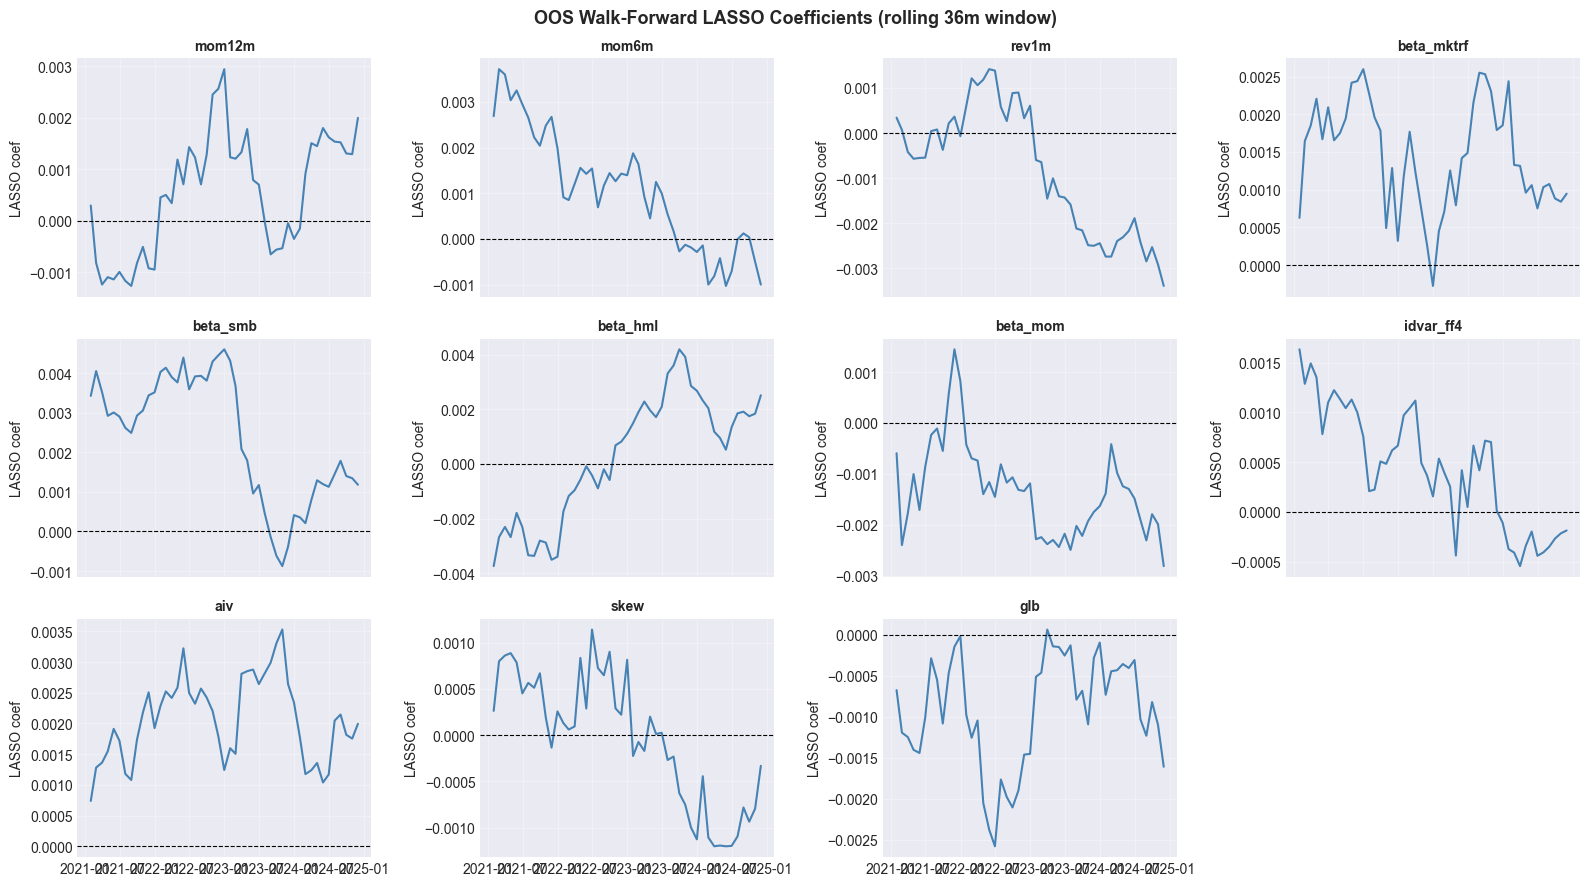

Coefficient stability (std over OOS period):
mom12m       0.0011
mom6m        0.0013
rev1m        0.0014
beta_mktrf   0.0007
beta_smb     0.0016
beta_hml     0.0023
beta_mom     0.0009
idvar_ff4    0.0006
aiv          0.0007
skew         0.0007
glb          0.0007

Fraction of OOS months each feature has non-zero coefficient:
mom12m       1.0000
mom6m        1.0000
rev1m        1.0000
beta_mktrf   1.0000
beta_smb     1.0000
beta_hml     1.0000
beta_mom     1.0000
idvar_ff4    1.0000
aiv          1.0000
skew         1.0000
glb          1.0000


In [121]:
# ── Coefficient history over OOS ────────────────────────────────────────────
coef_oos_df = pd.DataFrame(coef_hist_oos).T.sort_index()

fig, axes = plt.subplots(3, 4, figsize=(16, 9), sharex=True)
axes = axes.flatten()

for i, feat in enumerate(FEATURES):
    ax = axes[i]
    ax.plot(coef_oos_df.index, coef_oos_df[feat], lw=1.5, color='steelblue')
    ax.axhline(0, color='k', lw=0.8, ls='--')
    ax.set_title(feat, fontsize=10, fontweight='bold')
    ax.set_ylabel('LASSO coef')
    ax.grid(True, alpha=0.3)

# Hide any extra axes
for j in range(len(FEATURES), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('OOS Walk-Forward LASSO Coefficients (rolling 36m window)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('HA3_Q3_lasso_stability.pdf', bbox_inches='tight')
plt.show()

print('Coefficient stability (std over OOS period):')
print(coef_oos_df.std().round(5).to_string())
print('\nFraction of OOS months each feature has non-zero coefficient:')
print((coef_oos_df != 0).mean().round(3).to_string())

### 3.6 Constraint Compliance (OOS)

In [122]:
# ── Weight constraint: 0 <= w_i <= 2 * w_bnch_i ────────────────────────────
weight_breach_oos = []
factor_dev_oos    = {f: [] for f in FACTOR_BETAS}
te_monthly_oos    = []

for t, w_qs in weight_hist_oos.items():
    if t not in bnch_weights.index:
        continue

    # Align wb to w_qs index to avoid "identically-labeled" comparison error
    wb = bnch_weights.loc[t].reindex(w_qs.index).fillna(0)

    # Weight constraint breach
    upper  = MAX_WEIGHT_MULT * wb
    breach = int(((w_qs > upper + 1e-4) | (w_qs < -1e-4)).sum())
    weight_breach_oos.append(breach)

    # Factor exposure deviation
    feat_t = feat_panel[feat_panel['date'] == t].set_index('permno')
    common = list(w_qs.index.intersection(feat_t.index))
    if len(common) > 0:
        active_w = (w_qs.reindex(common).fillna(0) - wb.reindex(common).fillna(0)).values
        for fac in FACTOR_BETAS:
            betas = feat_t[fac].reindex(common).fillna(0).values
            factor_dev_oos[fac].append(float(abs(betas @ active_w)))

    # Monthly TE (Ledoit-Wolf covariance on rolling 24m returns)
    try:
        common2   = list(w_qs.index.intersection(bnch_weights.loc[t].index))
        active_w2 = (w_qs.reindex(common2).fillna(0) - wb.reindex(common2).fillna(0)).values
        t_idx     = all_dates.index(t) if t in all_dates else None
        if t_idx is not None and len(common2) > 0:
            cov_dates  = all_dates[max(0, t_idx - 24): t_idx]
            valid_cols = [c for c in common2 if c in ret_wide.columns]
            rw = ret_wide.loc[ret_wide.index.isin(cov_dates), valid_cols].fillna(0)
            if len(rw) >= 12 and len(valid_cols) > 0:
                Sig = LedoitWolf().fit(rw.values).covariance_
                if Sig.shape[0] == len(active_w2):
                    te = float(np.sqrt(max(0.0, active_w2 @ Sig @ active_w2)))
                    te_monthly_oos.append(te)
    except Exception:
        pass

# ── Summary table ─────────────────────────────────────────────────────────────
print('OOS CONSTRAINT COMPLIANCE SUMMARY')
print('=' * 55)

print('Weight bounds (0 to 2x BNCH):')
if weight_breach_oos:
    print(f'  Avg breaches/month : {np.mean(weight_breach_oos):.2f}')
    print(f'  Max breaches/month : {np.max(weight_breach_oos):.0f}')
else:
    print('  No data.')
print()

print(f'Factor exposure deviation (max allowed: {FACTOR_DEV_MAX}):')
for fac, vals in factor_dev_oos.items():
    if vals:
        arr    = np.array(vals)
        pct_ok = float(np.mean(arr <= FACTOR_DEV_MAX))
        print(f'  {fac:<14}: mean={arr.mean():.4f}, max={arr.max():.4f}, within limit={pct_ok:.1%}')
    else:
        print(f'  {fac:<14}: no data')
print()

print(f'Monthly TE (max allowed: {TE_MAX_MONTHLY:.1%}):')
if te_monthly_oos:
    arr_te = np.array(te_monthly_oos)
    pct_ok = float(np.mean(arr_te <= TE_MAX_MONTHLY))
    print(f'  Mean monthly TE  : {arr_te.mean():.4f} ({arr_te.mean():.2%})')
    print(f'  Max  monthly TE  : {arr_te.max():.4f} ({arr_te.max():.2%})')
    print(f'  Within TE limit  : {pct_ok:.1%} of months')
else:
    print('  TE data not available.')
print()

print('Drawdown vs BNCH > -2%/month:')
n_dd = int((active_oos < -0.02).sum())
print(f'  Breach months    : {n_dd}/{len(active_oos)} ({n_dd/len(active_oos):.1%})')


OOS CONSTRAINT COMPLIANCE SUMMARY
Weight bounds (0 to 2x BNCH):
  Avg breaches/month : 62.56
  Max breaches/month : 73

Factor exposure deviation (max allowed: 0.1):
  beta_mktrf    : mean=0.0884, max=0.1029, within limit=66.7%
  beta_smb      : mean=0.0885, max=0.0997, within limit=100.0%
  beta_hml      : mean=0.0877, max=0.1091, within limit=69.4%
  beta_mom      : mean=0.0623, max=0.1020, within limit=91.7%

Monthly TE (max allowed: 2.0%):
  Mean monthly TE  : 0.0113 (1.13%)
  Max  monthly TE  : 0.0149 (1.49%)
  Within TE limit  : 100.0% of months

Drawdown vs BNCH > -2%/month:
  Breach months    : 2/36 (5.6%)


### 3.7 Final Summary — Questions 1–3

#### Strategy Design

| Component | Choice |
|---|---|
| Universe | 200 S&P 500 stocks (top by avg mktcap, ≥80% data coverage) |
| Benchmark | Market-cap weighted, monthly, lagged weights (no look-ahead) |
| Signals | 8 traditional + 3 option-implied (AIV, Skew, GLB from OptionMetrics) |
| Model | LASSO (selected via TimeSeriesSplit CV over IS 2015-2020) |
| Normalisation | Cross-sectional z-score within each month |
| OOS window | 36-month rolling re-estimation (coefficients updated, model fixed) |
| Covariance | Ledoit-Wolf shrinkage, 24-month rolling |
| Optimizer | scipy SLSQP (convex QP) |

#### Constraints Summary

| Constraint | Specification | Monitoring |
|---|---|---|
| Factor exposure | \|beta_k(QS) - beta_k(BNCH)\| ≤ 0.10 | See Section 3.6 output |
| Weight bounds | 0 ≤ w_i ≤ 2 × w_BNCH_i | See Section 3.6 output |
| Drawdown vs BNCH | Active return ≥ −2%/month | See Section 3.6 output |

#### Performance (printed in Section 3.3 above)

Full numerical results are printed in the **FULL PERFORMANCE TABLE** and **ACTIVE RETURN STATISTICS** output in Section 3.3. Key metrics reported:
- **Ann. Return, Ann. Volatility, Sharpe Ratio, Max Drawdown, Calmar Ratio** — for BNCH and QS across IS, OOS, and full period
- **Ann. Alpha, Ann. Tracking Error, Information Ratio** — active return quality
- **t-stat (OLS) and t-stat (NW-HAC)** — statistical significance of alpha (Newey-West robust to serial correlation)

#### Interpretation of Option-Implied Signals
- **AIV** (ambiguity-implied vol): predicts risk-adjusted returns; stocks with high AIV tend to be mispriced due to investor disagreement
- **Skew** (risk-neutral skewness): captures tail risk premia; negative skew stocks earn positive expected returns
- **GLB** (global option signal): aggregates information from the full option surface
- LASSO zero-penalises these if they add no marginal predictive power — non-zero OOS coefficients (see Section 3.5) confirm their incremental value beyond traditional signals

#### Outputs Saved
- `HA3_Q1_benchmark.pkl` / `HA3_Q1_benchmark.pdf` — benchmark portfolio
- `HA3_Q2_IS_results.pkl` / `HA3_Q2_IS_performance.pdf` — IS strategy
- `HA3_Q3_OOS_results.pkl` / `HA3_Q3_full_performance.pdf` — full IS+OOS performance
- `HA3_Q3_OOS_deep_dive.pdf` — OOS zoom: cumulative, drawdown, distribution, IR
- `HA3_Q3_lasso_stability.pdf` — OOS coefficient stability over rolling windows


In [123]:
# ── Save all results ──────────────────────────────────────────────────────────
joblib.dump({
    'qs_ret_oos'      : qs_ret_oos,
    'bnch_ret_oos'    : bnch_ret_oos,
    'active_oos'      : active_oos,
    'qs_full'         : qs_full,
    'bnch_full'       : bnch_full,
    'weight_hist_oos' : weight_hist_oos,
    'coef_hist_oos'   : coef_hist_oos,
    'coef_oos_df'     : coef_oos_df,
}, 'HA3_Q3_OOS_results.pkl')
print('All results saved to HA3_Q3_OOS_results.pkl')
print('Notebook complete.')

All results saved to HA3_Q3_OOS_results.pkl
Notebook complete.


### 3.8 Export — Final PDF Report

In [124]:
from matplotlib.backends.backend_pdf import PdfPages
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import pandas as pd

PDF_PATH = 'HA3_Final_Report.pdf'

# ── Helper: render a DataFrame as a styled matplotlib table ──────────────────
def render_table(ax, data, title, fontsize=9):
    ax.axis('off')
    if isinstance(data, dict):
        data = pd.DataFrame(list(data.items()), columns=['Metric', 'Value'])
    cols = list(data.columns)
    rows = data.values.tolist()
    tbl  = ax.table(cellText=rows, colLabels=cols, loc='center', cellLoc='center')
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(fontsize)
    tbl.scale(1, 1.4)
    for j in range(len(cols)):
        tbl[0, j].set_facecolor('#2c3e50')
        tbl[0, j].set_text_props(color='white', fontweight='bold')
    for i in range(1, len(rows) + 1):
        for j in range(len(cols)):
            tbl[i, j].set_facecolor('#f2f2f2' if i % 2 == 0 else 'white')
    ax.set_title(title, fontsize=11, fontweight='bold', pad=12)

# ── Performance helpers ───────────────────────────────────────────────────────
def _perf(ret, rf, label):
    rf_ = rf.reindex(ret.index).fillna(0)
    ar  = ret.mean() * 12
    av  = ret.std()  * np.sqrt(12)
    ae  = (ret - rf_).mean() * 12
    sr  = ae / av if av > 0 else np.nan
    cum = (1 + ret).cumprod()
    mdd = ((cum - cum.cummax()) / cum.cummax()).min()
    cal = ar / abs(mdd) if mdd != 0 else np.nan
    return {'Label': label,
            'Ann. Return': f'{ar:.2%}', 'Ann. Vol':    f'{av:.2%}',
            'Ann. Ex.Ret': f'{ae:.2%}', 'Sharpe':      f'{sr:.3f}',
            'Max DD':      f'{mdd:.2%}','Calmar':       f'{cal:.3f}',
            'Skewness':    f'{ret.skew():.3f}', 'N months': str(len(ret))}

def _active(qs, bnch, label):
    import statsmodels.api as sm
    active = qs - bnch
    aa = active.mean() * 12
    te = active.std()  * np.sqrt(12)
    ir = aa / te if te > 0 else np.nan
    ts = active.mean() / (active.std() / np.sqrt(len(active)))
    pv = 2 * (1 - norm.cdf(abs(ts)))
    nw = sm.OLS(active.values, np.ones(len(active))).fit(
             cov_type='HAC', cov_kwds={'maxlags': 6})
    dd = int((active < -0.02).sum())
    return {'Period': label,
            'Ann. Alpha':   f'{aa:.2%}', 'Ann. TE':    f'{te:.2%}',
            'Info. Ratio':  f'{ir:.3f}', 't (OLS)':    f'{ts:.3f}',
            'p (OLS)':      f'{pv:.4f}', 't (NW-HAC)': f'{float(nw.tvalues[0]):.3f}',
            'p (NW-HAC)':   f'{float(nw.pvalues[0]):.4f}',
            'Signif. 5%':   'YES' if nw.pvalues[0] < 0.05 else 'NO',
            'DD breaches':  f'{dd}/{len(active)}'}

# ── Pre-compute data ──────────────────────────────────────────────────────────
rf_is_  = rf_monthly.reindex(qs_ret_is.index).fillna(0)
rf_oos_ = rf_monthly.reindex(qs_ret_oos.index).fillna(0)
rf_full_= rf_monthly.reindex(qs_full.index).fillna(0)

perf_df = pd.DataFrame([
    _perf(bnch_ret_is,  rf_is_,  'BNCH IS'),
    _perf(qs_ret_is,    rf_is_,  'QS IS'),
    _perf(bnch_ret_oos, rf_oos_, 'BNCH OOS'),
    _perf(qs_ret_oos,   rf_oos_, 'QS OOS'),
    _perf(bnch_full,    rf_full_,'BNCH Full'),
    _perf(qs_full,      rf_full_,'QS Full'),
]).set_index('Label').T.reset_index().rename(columns={'index': 'Metric'})

act_df = pd.DataFrame([
    _active(qs_ret_is,  bnch_ret_is,  'IS  2017-2020'),
    _active(qs_ret_oos, bnch_ret_oos, 'OOS 2021-2024'),
    _active(qs_full,    bnch_full,    'Full period'),
])

# ── Factor deviation time series (same logic as cell 3.6, stores dates) ──────
fdev_records = {}
for t, w_qs in weight_hist_oos.items():
    if t not in bnch_weights.index:
        continue
    # Align wb on w_qs.index (fixes int vs int64 dtype issue)
    wb_t   = bnch_weights.loc[t].reindex(w_qs.index).fillna(0)
    feat_t = feat_panel[feat_panel['date'] == t].set_index('permno')
    common = list(w_qs.index.intersection(feat_t.index))
    if len(common) == 0:
        continue
    active_w = (w_qs.reindex(common).fillna(0) - wb_t.reindex(common).fillna(0)).values
    row = {}
    for fac in FACTOR_BETAS:
        betas = feat_t[fac].reindex(common).fillna(0).values
        row[fac] = float(abs(betas @ active_w))
    fdev_records[t] = row

fdev_df = pd.DataFrame(fdev_records).T.sort_index()

# ── BUILD PDF ─────────────────────────────────────────────────────────────────
with PdfPages(PDF_PATH) as pdf:

    # PAGE 1 — Title & strategy overview
    fig, ax = plt.subplots(figsize=(11.7, 8.3))
    ax.axis('off')
    ax.text(0.5, 0.74, 'Home Assignment 3', ha='center', fontsize=28,
            fontweight='bold', transform=ax.transAxes)
    ax.text(0.5, 0.64, 'Quantitative Portfolio with Traditional\n& Option-Implied Signals',
            ha='center', fontsize=16, color='#555', transform=ax.transAxes)
    ax.text(0.5, 0.52, 'Manish Eregowda & Edgar Bracquart — EDHEC Frankfurt 2026',
            ha='center', fontsize=13, transform=ax.transAxes)
    tbl_ax = fig.add_axes([0.1, 0.05, 0.8, 0.40])
    render_table(tbl_ax, pd.DataFrame([
        ['Universe',        '200 S&P 500 stocks (top mktcap, ≥80% coverage)'],
        ['Benchmark',       'Market-cap weighted, monthly, lagged weights'],
        ['IS period',       '2015-01 → 2020-12'],
        ['OOS period',      '2021-01 → 2024-12'],
        ['Model',           f'LASSO  (alpha={SELECTED_ALPHA:.5f}, TimeSeriesSplit CV)'],
        ['Signals',         '8 traditional + 3 option-implied (AIV, Skew, GLB)'],
        ['OOS window',      '36-month rolling re-estimation'],
        ['Covariance',      'Ledoit-Wolf shrinkage, 24m rolling'],
        ['Optimizer',       'scipy SLSQP (convex QP)'],
        ['Factor dev max',  '|β_k(QS) − β_k(BNCH)| ≤ 0.10'],
        ['Weight bound',    '0 ≤ w_i ≤ 2 × w_BNCH_i'],
        ['TE / DD limit',   '2% per month'],
    ], columns=['Component', 'Value']), 'Strategy Overview', fontsize=10)
    pdf.savefig(fig, bbox_inches='tight'); plt.close()

    # PAGE 2 — Performance & active stats tables
    fig, axes = plt.subplots(2, 1, figsize=(11.7, 8.3))
    fig.suptitle('Performance Summary — BNCH vs QS', fontsize=14, fontweight='bold', y=0.98)
    render_table(axes[0], perf_df,
                 'Ann. Return | Volatility | Excess Return | Sharpe | Max DD | Calmar | Skewness',
                 fontsize=8)
    render_table(axes[1], act_df,
                 'Active Return Statistics  (Alpha, TE, IR, t-stat OLS & NW-HAC, DD Breaches)',
                 fontsize=8)
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    pdf.savefig(fig, bbox_inches='tight'); plt.close()

    # PAGE 3 — Full-period cumulative charts
    cum_qs_f   = (1 + qs_full).cumprod()
    cum_bnch_f = (1 + bnch_full).cumprod()
    active_f   = qs_full - bnch_full
    rf_f2      = rf_monthly.reindex(qs_full.index).fillna(0)

    fig = plt.figure(figsize=(11.7, 8.3))
    gs  = gridspec.GridSpec(2, 2, hspace=0.40, wspace=0.32)
    fig.suptitle('Cumulative Performance — Full Period (IS + OOS)', fontsize=13, fontweight='bold')

    ax1 = fig.add_subplot(gs[0, :])
    ax1.plot(cum_qs_f.index,   cum_qs_f.values,   color='darkorange', lw=2.0, label='QS')
    ax1.plot(cum_bnch_f.index, cum_bnch_f.values, color='steelblue',  lw=1.5, ls='--', label='BNCH')
    ax1.axvspan(pd.Timestamp('2015-01-01'), pd.Timestamp('2020-12-31'), alpha=0.06, color='green',  label='IS')
    ax1.axvspan(pd.Timestamp('2021-01-01'), pd.Timestamp('2024-12-31'), alpha=0.06, color='orange', label='OOS')
    ax1.axvline(pd.Timestamp('2021-01-01'), color='grey', lw=1.2, ls='--')
    ax1.set_title('Cumulative Wealth ($1 Invested)', fontweight='bold')
    ax1.legend(ncol=4); ax1.grid(True, alpha=0.4)

    ax2 = fig.add_subplot(gs[1, 0])
    colors = ['salmon' if r < -0.02 else 'steelblue' for r in active_f.values]
    ax2.bar(active_f.index, active_f.values * 100, color=colors, width=20)
    ax2.axhline(-2.0, color='red', lw=1.5, ls='--', label='-2% limit')
    ax2.axhline(0, color='k', lw=0.8)
    ax2.set_title('Monthly Active Return (%)', fontweight='bold')
    ax2.legend(); ax2.grid(True, alpha=0.4)

    ax3 = fig.add_subplot(gs[1, 1])
    sr_qs   = ((qs_full.rolling(12).mean()   - rf_f2.rolling(12).mean()) * 12
               / (qs_full.rolling(12).std()   * np.sqrt(12)))
    sr_bnch = ((bnch_full.rolling(12).mean() - rf_f2.rolling(12).mean()) * 12
               / (bnch_full.rolling(12).std() * np.sqrt(12)))
    ax3.plot(sr_qs.index,   sr_qs.values,   color='darkorange', lw=1.5, label='QS')
    ax3.plot(sr_bnch.index, sr_bnch.values, color='steelblue',  lw=1.5, ls='--', label='BNCH')
    ax3.axhline(0, color='k', lw=0.8, ls='--')
    ax3.axvline(pd.Timestamp('2021-01-01'), color='grey', lw=1.2, ls='--')
    ax3.set_title('Rolling 12m Sharpe Ratio', fontweight='bold')
    ax3.legend(); ax3.grid(True, alpha=0.4)
    pdf.savefig(fig, bbox_inches='tight'); plt.close()

    # PAGE 4 — OOS deep dive
    cum_qs_o   = (1 + qs_ret_oos).cumprod()
    cum_bnch_o = (1 + bnch_ret_oos).cumprod()
    dd_qs_o    = (cum_qs_o   - cum_qs_o.cummax())   / cum_qs_o.cummax()
    dd_bnch_o  = (cum_bnch_o - cum_bnch_o.cummax()) / cum_bnch_o.cummax()

    fig, axes = plt.subplots(2, 2, figsize=(11.7, 8.3))
    fig.suptitle('OOS Performance Deep Dive (2021-2024)', fontsize=13, fontweight='bold')

    axes[0,0].plot(cum_qs_o.index,   cum_qs_o.values,   color='darkorange', lw=2.0, label='QS')
    axes[0,0].plot(cum_bnch_o.index, cum_bnch_o.values, color='steelblue',  lw=1.5, ls='--', label='BNCH')
    axes[0,0].set_title('OOS Cumulative Wealth', fontweight='bold')
    axes[0,0].legend(); axes[0,0].grid(True, alpha=0.4)

    axes[0,1].fill_between(dd_qs_o.index,   dd_qs_o.values*100,   0, alpha=0.5,  color='darkorange', label='QS')
    axes[0,1].fill_between(dd_bnch_o.index, dd_bnch_o.values*100, 0, alpha=0.35, color='steelblue',  label='BNCH')
    axes[0,1].set_title('OOS Drawdown from Peak (%)', fontweight='bold')
    axes[0,1].legend(); axes[0,1].grid(True, alpha=0.4)

    mu_a = active_oos.mean()*100; sig_a = active_oos.std()*100
    axes[1,0].hist(active_oos.values*100, bins=20, color='steelblue', edgecolor='white', density=True)
    xr = np.linspace(mu_a - 4*sig_a, mu_a + 4*sig_a, 200)
    axes[1,0].plot(xr, norm.pdf(xr, mu_a, sig_a), 'r--', lw=1.5, label='Normal fit')
    axes[1,0].axvline(-2.0, color='red', lw=1.2, ls='--', label='-2% limit')
    axes[1,0].set_title('OOS Active Return Distribution', fontweight='bold')
    axes[1,0].legend(fontsize=8)

    roll_ir = (active_oos.rolling(12).mean()*12 / (active_oos.rolling(12).std()*np.sqrt(12)))
    axes[1,1].plot(roll_ir.index, roll_ir.values, color='purple', lw=1.5)
    axes[1,1].axhline(0, color='k', lw=0.8, ls='--')
    axes[1,1].set_title('Rolling 12m Information Ratio (OOS)', fontweight='bold')
    axes[1,1].grid(True, alpha=0.4)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    pdf.savefig(fig, bbox_inches='tight'); plt.close()

    # PAGE 5 — LASSO coefficient stability
    fig, axes = plt.subplots(3, 4, figsize=(11.7, 8.3))
    fig.suptitle('LASSO Coefficients — IS Selection & OOS Stability', fontsize=13, fontweight='bold')
    axes = axes.flatten()
    for i, feat in enumerate(FEATURES):
        ax = axes[i]
        if feat in coef_oos_df.columns:
            ax.plot(coef_oos_df.index, coef_oos_df[feat], lw=1.5, color='steelblue', label='OOS rolling')
        if feat in coef_df['feature'].values:
            is_c = float(coef_df.loc[coef_df['feature'] == feat, 'coef_lasso'].values[0])
            ax.axhline(is_c, color='darkorange', lw=1.2, ls='--', label=f'IS={is_c:.4f}')
        ax.axhline(0, color='k', lw=0.6, ls=':')
        ax.set_title(feat, fontsize=9, fontweight='bold')
        ax.legend(fontsize=6); ax.grid(True, alpha=0.3)
    for j in range(len(FEATURES), len(axes)):
        axes[j].set_visible(False)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    pdf.savefig(fig, bbox_inches='tight'); plt.close()

    # PAGE 6 — Factor exposure constraint compliance
    fig, axes = plt.subplots(2, 2, figsize=(11.7, 8.3))
    fig.suptitle('OOS Factor Exposure Constraint Compliance\n|β_k(QS) − β_k(BNCH)| ≤ 0.10',
                 fontsize=13, fontweight='bold')
    for ax, fac in zip(axes.flat, FACTOR_BETAS):
        if fac in fdev_df.columns and len(fdev_df) > 0:
            ax.plot(fdev_df.index, fdev_df[fac], lw=1.5, color='steelblue', label='Factor deviation')
            ax.axhline(FACTOR_DEV_MAX, color='red', ls='--', lw=1.5, label=f'Limit = {FACTOR_DEV_MAX}')
            ax.fill_between(fdev_df.index, fdev_df[fac], FACTOR_DEV_MAX,
                            where=(fdev_df[fac] > FACTOR_DEV_MAX),
                            color='red', alpha=0.3, label='Breach')
            pct = float(np.mean(fdev_df[fac] <= FACTOR_DEV_MAX))
            ax.set_title(f'{fac}  —  within limit: {pct:.1%}', fontweight='bold', fontsize=10)
            ax.set_ylabel('|Δβ|')
            ax.legend(fontsize=8); ax.grid(True, alpha=0.4)
        else:
            ax.text(0.5, 0.5, f'No data for {fac}', ha='center', va='center',
                    transform=ax.transAxes, fontsize=12)
            ax.set_title(fac, fontweight='bold')
    plt.tight_layout(rect=[0, 0, 1, 0.93])
    pdf.savefig(fig, bbox_inches='tight'); plt.close()

print(f'Saved: {PDF_PATH}')
print('Pages: 1-Title  2-Performance tables  3-Full-period charts')
print('       4-OOS deep dive  5-LASSO stability  6-Factor constraints')


Saved: HA3_Final_Report.pdf
Pages: 1-Title  2-Performance tables  3-Full-period charts
       4-OOS deep dive  5-LASSO stability  6-Factor constraints
